In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Configurar el estilo de los gráficos
plt.style.use('ggplot')

In [2]:
def calcular_riqueza_lexica(texto):
    # Convertir a minúsculas y extraer solo palabras
    palabras = re.findall(r'[a-záéíóúñü]+', texto.lower())
    total_tokens = len(palabras)
    
    # Prevención de error si hay un archivo vacío
    if total_tokens == 0:
        return 0, 0, 0
    
    # Calcular Tipos y TTR
    vocabulario = set(palabras)
    total_types = len(vocabulario)
    ttr = total_types / total_tokens
    
    # Calcular Hapax Legomena
    frecuencias = Counter(palabras)
    hapax = sum(1 for p, count in frecuencias.items() if count == 1)
    hapax_richness = hapax / total_tokens
    
    return total_tokens, ttr, hapax_richness

In [ ]:
def analizar_novela(ruta_archivo):
    with open(ruta_archivo, 'r', encoding='utf-8') as f:
        texto = f.read().lower()
        # Solo palabras, ignora números y puntuación
        palabras = re.findall(r'[a-záéíóúüñ]+', texto)
        
        total_tokens = len(palabras)
        vocabulario = set(palabras)
        total_types = len(vocabulario)
        
        ttr = total_types / total_tokens
        
        conteo = Counter(palabras)
        hapax = sum(1 for p in conteo if conteo[p] == 1)
        hapax_richness = hapax / total_tokens
        
        return total_tokens, ttr, hapax_richness

In [ ]:
import os
import re
import pandas as pd
from collections import Counter

RUTA_TEXTOS = "Textos"
reporte_global = []

for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt"):
        ruta_completa = os.path.join(RUTA_TEXTOS, archivo)
        
        with open(ruta_completa, 'r', encoding='utf-8') as f:
            texto = f.read()
        
        # Limpieza
        palabras = re.findall(r'[a-záéíóúñü]+', texto.lower())
        total_tokens = len(palabras)
        
        if total_tokens > 0:
            vocabulario = set(palabras)
            total_types = len(vocabulario)
            ttr = total_types / total_tokens
            
            frecuencias = Counter(palabras)
            total_hapax = sum(1 for count in frecuencias.values() if count == 1)
            hapax_richness = total_hapax / total_tokens
        else:
            total_types = ttr = total_hapax = hapax_richness = 0
            
        # Extraer el nombre limpio
        nombre_libro = archivo.replace(".txt", "")
            
        # Guardar en la lista
        reporte_global.append({
            "Libro": nombre_libro,
            "Tokens (Tamaño)": total_tokens,
            "Types (Vocabulario)": total_types,
            "TTR Bruto": round(ttr, 4),
            "Hapax (Únicas)": total_hapax,
            "Hapax Richness": round(hapax_richness, 4)
        })

# Convertir a DataFrame
df_reporte = pd.DataFrame(reporte_global)

# Ordenar por Tamaño (Tokens) de menor a mayor para ver el efecto de la longitud
df_reporte = df_reporte.sort_values(by="Tokens (Tamaño)")

# Guardar este reporte en un CSV
df_reporte.to_csv("Reporte_Completo_Metricas.csv", index=False, encoding='utf-8')

# Mostrar la tabla en VS Code
df_reporte

,Libro,Tokens (Tamaño),Types (Vocabulario),TTR Bruto,Hapax (Únicas),Hapax Richness
35,1858_Eugenio Diaz Castro_Una ronda de don Vent...,7845,2242,0.2858,1566,0.1996
2,1973_Alvaro Mutis_La mansion de Araucaima,8483,2577,0.3038,1828,0.2155
47,1863_Jose Maria Vergara y Vergara_Las tres tazas,9823,2893,0.2945,1954,0.1989
32,1952_Jorge Zalamea_El Gran Burundun-Burunda ha...,12767,4226,0.3310,3225,0.2526
75,1961_Gabriel Garcia Marquez_El coronel no tien...,17385,3455,0.1987,2054,0.1181
...,...,...,...,...,...,...
34,1983_Manuel Zapata Olivella_Chango el gran putas,168836,21481,0.1272,11409,0.0676
33,2016_Ricardo Silva Romero_Historia oficial del...,175214,16059,0.0917,8487,0.0484
11,1982_German Espinosa_La tejedora de coronas,181032,25286,0.1397,14241,0.0787
29,1986_Prospero Morales Pradilla_Los pecados de ...,216418,19223,0.0888,9521,0.0440


In [ ]:
%pip install seaborn


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install networkx


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Analizando la respiración de todas las novelas (con outliers)...


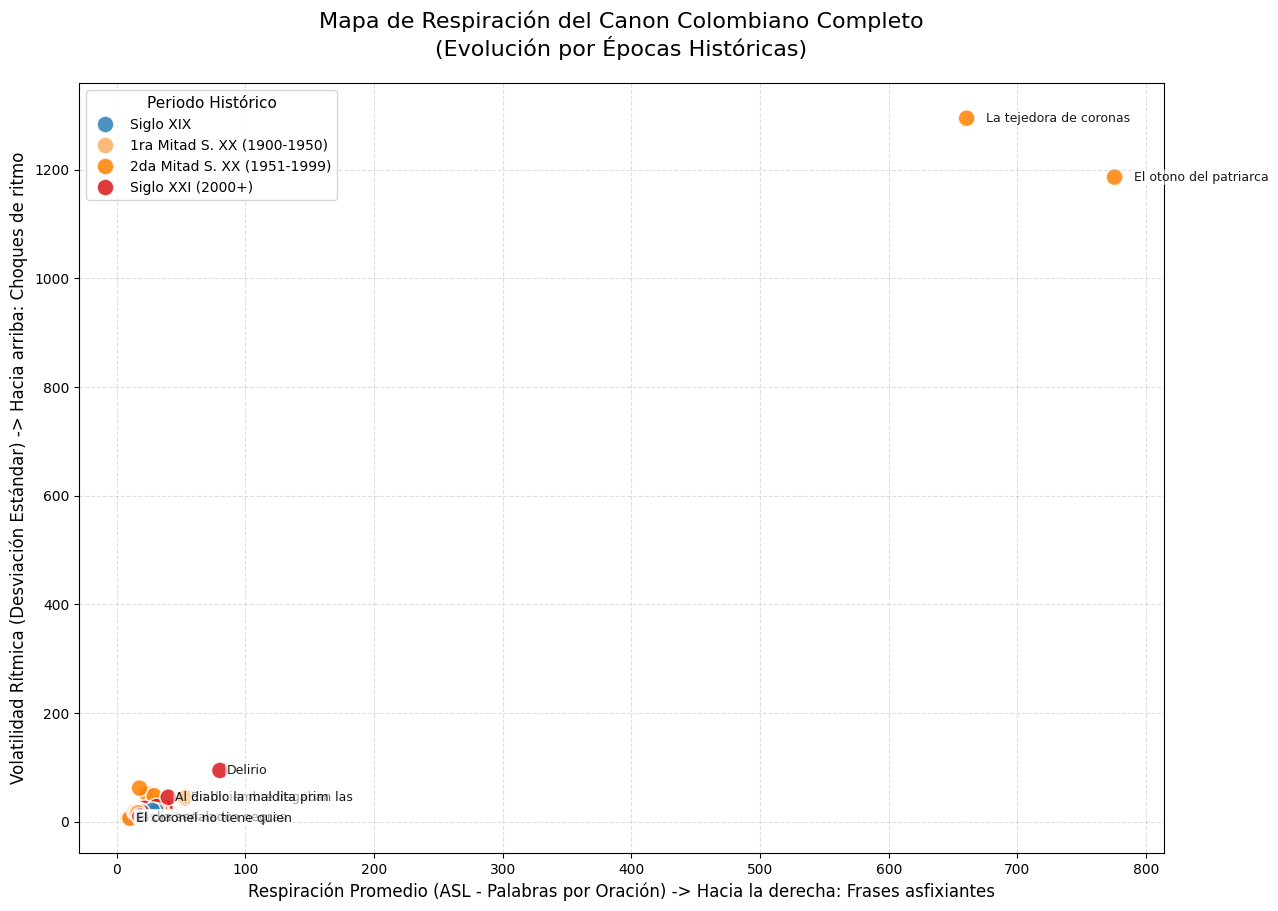

LAS 3 NOVELAS CON RESPIRACIÓN MÁS RÁPIDA (Frases más cortas):
- Las estrellas son negras (9.1 palabras/oración)
- Sin remedio (9.45 palabras/oración)
- Los abismos (10.09 palabras/oración)
LAS 3 NOVELAS MÁS ASFIXIANTES (Incluyendo anomalías):
- El otono del patriarca (775.44 palabras/oración)
- La tejedora de coronas (660.5 palabras/oración)
- Delirio (80.37 palabras/oración)


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
# fonttype 42 obliga a Matplotlib a incrustar las fuentes como texto editable
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# =========================================================
# 1. Función para medir el Ritmo y la Volatilidad
# =========================================================
def medir_respiracion(texto):
    oraciones = re.split(r'[.!?]+', texto)
    longitudes = []
    
    for oracion in oraciones:
        palabras = re.findall(r'\b\w+\b', oracion)
        if len(palabras) > 0:
            longitudes.append(len(palabras))
            
    if not longitudes:
        return 0, 0
        
    promedio_palabras = np.mean(longitudes)
    volatilidad = np.std(longitudes)
    
    return round(promedio_palabras, 2), round(volatilidad, 2)

# =========================================================
# 2. Asignación de Épocas Categóricas
# =========================================================
def categorizar_epoca(anio):
    if anio <= 1899:
        return "Siglo XIX"
    elif 1900 <= anio <= 1950:
        return "1ra Mitad S. XX (1900-1950)"
    elif 1951 <= anio <= 1999:
        return "2da Mitad S. XX (1951-1999)"
    else:
        return "Siglo XXI (2000+)"

# =========================================================
# 3. Procesamiento de los Textos
# =========================================================
RUTA_TEXTOS = "Textos" 
datos = []

print("Analizando la respiración de todas las novelas (con outliers)...")
for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
            texto = f.read()
            
        partes = archivo.replace(".txt", "").split("_")
        anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 0
        autor = partes[1].strip() if len(partes) > 1 else "Desconocido"
        titulo = partes[2].strip() if len(partes) > 2 else archivo
        
        promedio, volatilidad = medir_respiracion(texto)
        
        datos.append({
            "Año": anio,
            "Época": categorizar_epoca(anio),
            "Autor": autor,
            "Título": titulo,
            "Respiración_Promedio": promedio,
            "Volatilidad_Rítmica": volatilidad
        })

df = pd.DataFrame(datos)
df = df[df["Año"] > 1800] # Filtramos errores de año 0

# =========================================================
# 4. Visualización del Mapa Rítmico Completo (Categórico)
# =========================================================
# Paleta de colores para las épocas
paleta = {
    "Siglo XIX": "#2c7fb8",                  
    "1ra Mitad S. XX (1900-1950)": "#fdae61", 
    "2da Mitad S. XX (1951-1999)": "#ff8000", 
    "Siglo XXI (2000+)": "#d7191c"             
}

plt.figure(figsize=(14, 10))

# Seaborn scatterplot para manejar fácilmente las categorías
ax = sns.scatterplot(
    data=df,
    x="Respiración_Promedio",
    y="Volatilidad_Rítmica",
    hue="Época",
    hue_order=["Siglo XIX", "1ra Mitad S. XX (1900-1950)", "2da Mitad S. XX (1951-1999)", "Siglo XXI (2000+)"],
    palette=paleta,
    s=150,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

plt.title("Mapa de Respiración del Canon Colombiano Completo\n(Evolución por Épocas Históricas)", fontsize=16, pad=20)
plt.xlabel("Respiración Promedio (ASL - Palabras por Oración) -> Hacia la derecha: Frases asfixiantes", fontsize=12)
plt.ylabel("Volatilidad Rítmica (Desviación Estándar) -> Hacia arriba: Choques de ritmo", fontsize=12)
plt.grid(True, alpha=0.4, linestyle='--')

# Ajustar la leyenda
plt.legend(title="Periodo Histórico", title_fontsize='11', fontsize='10', loc='upper left')

# =========================================================
# 5. Etiquetado Inteligente (Top 5 más rápidas + Outliers)
# =========================================================
df_ordenado = df.sort_values(by="Respiración_Promedio")
top_5_rapidas = df_ordenado.head(5)["Título"].tolist()
top_5_lentas = df_ordenado.tail(5)["Título"].tolist()

promedio_x = df["Respiración_Promedio"].mean()
promedio_y = df["Volatilidad_Rítmica"].mean()

for i in range(len(df)):
    x = df["Respiración_Promedio"].iloc[i]
    y = df["Volatilidad_Rítmica"].iloc[i]
    titulo = df["Título"].iloc[i]
    
    # Condición para rotular: Es de las 5 más cortas, las 5 más largas o está fuera de la norma general
    if (titulo in top_5_rapidas) or (titulo in top_5_lentas) or \
       (abs(x - promedio_x) > df["Respiración_Promedio"].std() * 1.5) or \
       (abs(y - promedio_y) > df["Volatilidad_Rítmica"].std() * 1.5):
        
        # Añadimos un pequeño margen para que el texto no tape el punto
        margen = 5 if x < 100 else 15
        plt.text(x + margen, y, titulo[:25], fontsize=9, alpha=0.9, va='center', ha='left',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.1'))

plt.savefig("Mapa_Respiracion_Ritmica_Completo_Categorico.svg", format="svg", bbox_inches="tight")
plt.savefig("Mapa_Respiracion_Ritmica_Categorico.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Imprimir los extremos en consola
print("LAS 3 NOVELAS CON RESPIRACIÓN MÁS RÁPIDA (Frases más cortas):")
for i, row in df_ordenado.head(3).iterrows():
    print(f"- {row['Título']} ({row['Respiración_Promedio']} palabras/oración)")

print("LAS 3 NOVELAS MÁS ASFIXIANTES (Incluyendo anomalías):")
for i, row in df_ordenado.tail(3).iloc[::-1].iterrows():
    print(f"- {row['Título']} ({row['Respiración_Promedio']} palabras/oración)")

Analizando la respiración de las novelas...
Se excluyeron los outliers. Analizando 80 novelas...
LAS NOVELAS DEL CÍRCULO NEGRO (Ritmo Acelerado / Minimalista):
- Las estrellas son negras (ASL: 9.1 | Vol: 7.77) - 1ra Mitad S. XX (1900-1950)
- Sin remedio (ASL: 9.45 | Vol: 9.67) - 2da Mitad S. XX (1951-1999)
- Los abismos (ASL: 10.09 | Vol: 8.17) - Siglo XXI (2000+)
- El coronel no tiene quien le escriba (ASL: 10.46 | Vol: 6.72) - 2da Mitad S. XX (1951-1999)
- El dia senalado (ASL: 10.85 | Vol: 8.67) - 2da Mitad S. XX (1951-1999)
- Cuatro anos a bordo de mi mismo (ASL: 10.97 | Vol: 8.69) - 1ra Mitad S. XX (1900-1950)
- Perder es cuestion de metodo (ASL: 11.65 | Vol: 10.83) - 2da Mitad S. XX (1951-1999)
- La rebelion de las ratas (ASL: 11.82 | Vol: 10.62) - 2da Mitad S. XX (1951-1999)
- La Ceniza Del Libertador (ASL: 11.93 | Vol: 10.64) - 2da Mitad S. XX (1951-1999)
- La casa de las dos palmas (ASL: 12.67 | Vol: 10.87) - 2da Mitad S. XX (1951-1999)
- En Chima nace un santo (ASL: 12.9 | Vo

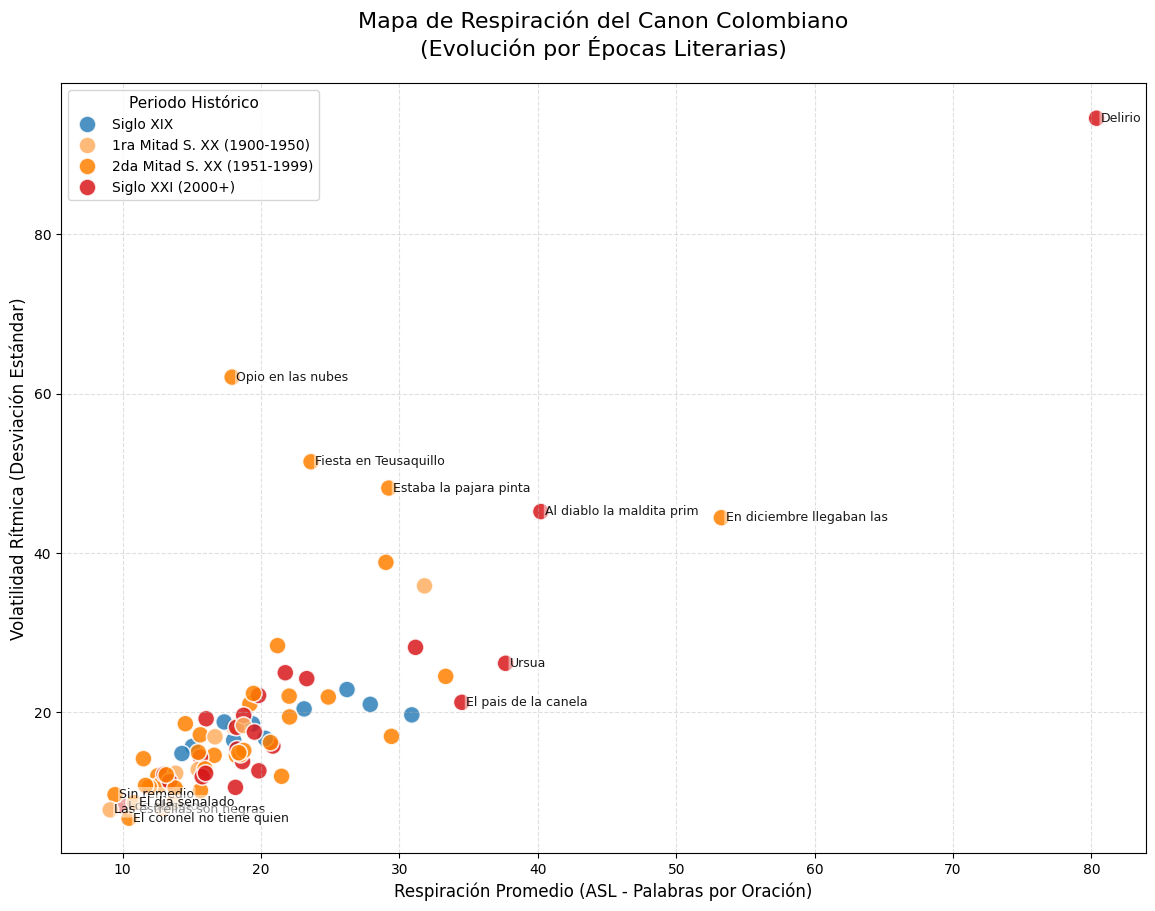

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib
# fonttype 42 obliga a Matplotlib a incrustar las fuentes como texto editable
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# =========================================================
# 1. Función para medir el Ritmo y la Volatilidad
# =========================================================
def medir_respiracion(texto):
    oraciones = re.split(r'[.!?]+', texto)
    longitudes = []
    
    for oracion in oraciones:
        palabras = re.findall(r'\b\w+\b', oracion)
        if len(palabras) > 0:
            longitudes.append(len(palabras))
            
    if not longitudes:
        return 0, 0
        
    promedio_palabras = np.mean(longitudes)
    volatilidad = np.std(longitudes)
    
    return round(promedio_palabras, 2), round(volatilidad, 2)

# =========================================================
# 2. Asignación de Épocas Categóricas
# =========================================================
def categorizar_epoca(anio):
    if anio <= 1899:
        return "Siglo XIX"
    elif 1900 <= anio <= 1950:
        return "1ra Mitad S. XX (1900-1950)"
    elif 1951 <= anio <= 1999:
        return "2da Mitad S. XX (1951-1999)"
    else:
        return "Siglo XXI (2000+)"

# =========================================================
# 3. Procesamiento de los Textos
# =========================================================
RUTA_TEXTOS = "Textos" 
datos = []

print("Analizando la respiración de las novelas...")
for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
            texto = f.read()
            
        partes = archivo.replace(".txt", "").split("_")
        anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 0
        autor = partes[1].strip() if len(partes) > 1 else "Desconocido"
        titulo = partes[2].strip() if len(partes) > 2 else archivo
        
        promedio, volatilidad = medir_respiracion(texto)
        
        datos.append({
            "Año": anio,
            "Época": categorizar_epoca(anio),
            "Autor": autor,
            "Título": titulo,
            "Respiración_Promedio": promedio,
            "Volatilidad_Rítmica": volatilidad
        })

df_master = pd.DataFrame(datos)
df_master = df_master[df_master["Año"] > 1800]

# Excluimos las novelas atípicas extremas
df_zoom = df_master[~df_master["Título"].str.contains("tejedora|patriarca", case=False)].copy()

print(f"Se excluyeron los outliers. Analizando {len(df_zoom)} novelas...")

# =========================================================
# 4. Visualización del Mapa Rítmico (Categórico)
# =========================================================
# Paleta de colores para las épocas
paleta = {
    "Siglo XIX": "#2c7fb8",                   
    "1ra Mitad S. XX (1900-1950)": "#fdae61", 
    "2da Mitad S. XX (1951-1999)": "#ff8000b7", 
    "Siglo XXI (2000+)": "#d7191c"            
}

plt.figure(figsize=(14, 10))

# Seaborn scatterplot para manejar categorías y leyenda
ax = sns.scatterplot(
    data=df_zoom,
    x="Respiración_Promedio",
    y="Volatilidad_Rítmica",
    hue="Época",
    hue_order=["Siglo XIX", "1ra Mitad S. XX (1900-1950)", "2da Mitad S. XX (1951-1999)", "Siglo XXI (2000+)"],
    palette=paleta,
    s=150,
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

plt.title("Mapa de Respiración del Canon Colombiano\n(Evolución por Épocas Literarias)", fontsize=16, pad=20)
plt.xlabel("Respiración Promedio (ASL - Palabras por Oración)", fontsize=12)
plt.ylabel("Volatilidad Rítmica (Desviación Estándar)", fontsize=12)
plt.grid(True, alpha=0.4, linestyle='--')

# Ajustar la leyenda
plt.legend(title="Periodo Histórico", title_fontsize='11', fontsize='10', loc='upper left')

# =========================================================
# 5. Etiquetado Inteligente (Top 5 más rápidas + Outliers)
# =========================================================
df_ordenado = df_zoom.sort_values(by="Respiración_Promedio")
top_5_rapidas = df_ordenado.head(5)["Título"].tolist()
top_5_lentas = df_ordenado.tail(5)["Título"].tolist()

promedio_x = df_zoom["Respiración_Promedio"].mean()
promedio_y = df_zoom["Volatilidad_Rítmica"].mean()

for i in range(len(df_zoom)):
    x = df_zoom["Respiración_Promedio"].iloc[i]
    y = df_zoom["Volatilidad_Rítmica"].iloc[i]
    titulo = df_zoom["Título"].iloc[i]
    
    # Condición para rotular: Es de las 5 más cortas, las 5 más largas, o está muy lejos del centro
    if (titulo in top_5_rapidas) or (titulo in top_5_lentas) or \
       (abs(x - promedio_x) > df_zoom["Respiración_Promedio"].std() * 1.5) or \
       (abs(y - promedio_y) > df_zoom["Volatilidad_Rítmica"].std() * 1.5):
        
        plt.text(x + 0.3, y, titulo[:25], fontsize=9, alpha=0.9, va='center', ha='left',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.1'))
        
        # Filtrar exactamente el cuadrante que marcaste en tu captura
cluster_rapido = df_zoom[
    (df_zoom["Respiración_Promedio"] < 13) & 
    (df_zoom["Volatilidad_Rítmica"] < 12)
].sort_values(by="Respiración_Promedio")

print("LAS NOVELAS DEL CÍRCULO NEGRO (Ritmo Acelerado / Minimalista):")
for i, row in cluster_rapido.iterrows():
    print(f"- {row['Título']} (ASL: {row['Respiración_Promedio']} | Vol: {row['Volatilidad_Rítmica']}) - {row['Época']}")

plt.savefig("Mapa_Respiracion_Ritmica_Categorico.svg", format="svg", bbox_inches="tight")
plt.savefig("Mapa_Respiracion_Ritmica_Categorico.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [9]:
# =========================================================
# 6. EXTRACCIÓN DE LOS EXTREMOS BARROCOS Y ARRÍTMICOS
# =========================================================

# 1. Novelas con ASL > 30 (La asfixia sintáctica)
asl_alto = df[df["Respiración_Promedio"] > 30].sort_values(by="Respiración_Promedio", ascending=False)

print("\n NOVELAS CON RESPIRACIÓN ASFIXIANTE (ASL > 30 palabras/oración):")
for i, row in asl_alto.iterrows():
    print(f"- {row['Título'][:30]}... | ASL: {row['Respiración_Promedio']} | Época: {row['Época']}")


# 2. Novelas con Volatilidad > 30 (El choque rítmico)
vol_alta = df[df["Volatilidad_Rítmica"] > 30].sort_values(by="Volatilidad_Rítmica", ascending=False)

print("\n NOVELAS CON ALTA VOLATILIDAD RÍTMICA (Desv. Estándar > 30):")
for i, row in vol_alta.iterrows():
    print(f"- {row['Título'][:30]}... | Volatilidad: {row['Volatilidad_Rítmica']} | Época: {row['Época']}")


 NOVELAS CON RESPIRACIÓN ASFIXIANTE (ASL > 30 palabras/oración):
- El otono del patriarca... | ASL: 775.44 | Época: 2da Mitad S. XX (1951-1999)
- La tejedora de coronas... | ASL: 660.5 | Época: 2da Mitad S. XX (1951-1999)
- Delirio... | ASL: 80.37 | Época: Siglo XXI (2000+)
- En diciembre llegaban las bris... | ASL: 53.26 | Época: 2da Mitad S. XX (1951-1999)
- Al diablo la maldita primavera... | ASL: 40.22 | Época: Siglo XXI (2000+)
- Ursua... | ASL: 37.67 | Época: Siglo XXI (2000+)
- El pais de la canela... | ASL: 34.51 | Época: Siglo XXI (2000+)
- Condores no entierran todos lo... | ASL: 33.34 | Época: 2da Mitad S. XX (1951-1999)
- De sobremesa... | ASL: 31.81 | Época: 1ra Mitad S. XX (1900-1950)
- El olvido que seremos... | ASL: 31.16 | Época: Siglo XXI (2000+)
- Ingermina... | ASL: 30.89 | Época: Siglo XIX

 NOVELAS CON ALTA VOLATILIDAD RÍTMICA (Desv. Estándar > 30):
- La tejedora de coronas... | Volatilidad: 1294.41 | Época: 2da Mitad S. XX (1951-1999)
- El otono del patriarca...

1. Cargando Spacy...
2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos y Verbos)...
ADN extraído: Ingermina...
ADN extraído: Manuela...
ADN extraído: Una ronda de don Ven...
ADN extraído: Las tres tazas...
ADN extraído: Maria...
ADN extraído: Una holandesa en Ame...
ADN extraído: El Alferez Real...
ADN extraído: Transito...
ADN extraído: Frutos de mi tierra...
ADN extraído: El Moro...
ADN extraído: Inocencia...
ADN extraído: Pax...
ADN extraído: Diana cazadora...
ADN extraído: La voragine...
ADN extraído: De sobremesa...
ADN extraído: Cosme...
ADN extraído: La Marquesa de Yolom...
ADN extraído: Cuatro anos a bordo ...
ADN extraído: Las estrellas son ne...
ADN extraído: El Cristo de espalda...
ADN extraído: El Gran Burundun-Bur...
ADN extraído: El dia de odio...
ADN extraído: Siervo sin tierra...
ADN extraído: El coronel no tiene ...
ADN extraído: La Casa Grande...
ADN extraído: La rebelion de las r...
ADN extraído: Catalina...
ADN extraído: El Hostigante Verano...
ADN extraíd

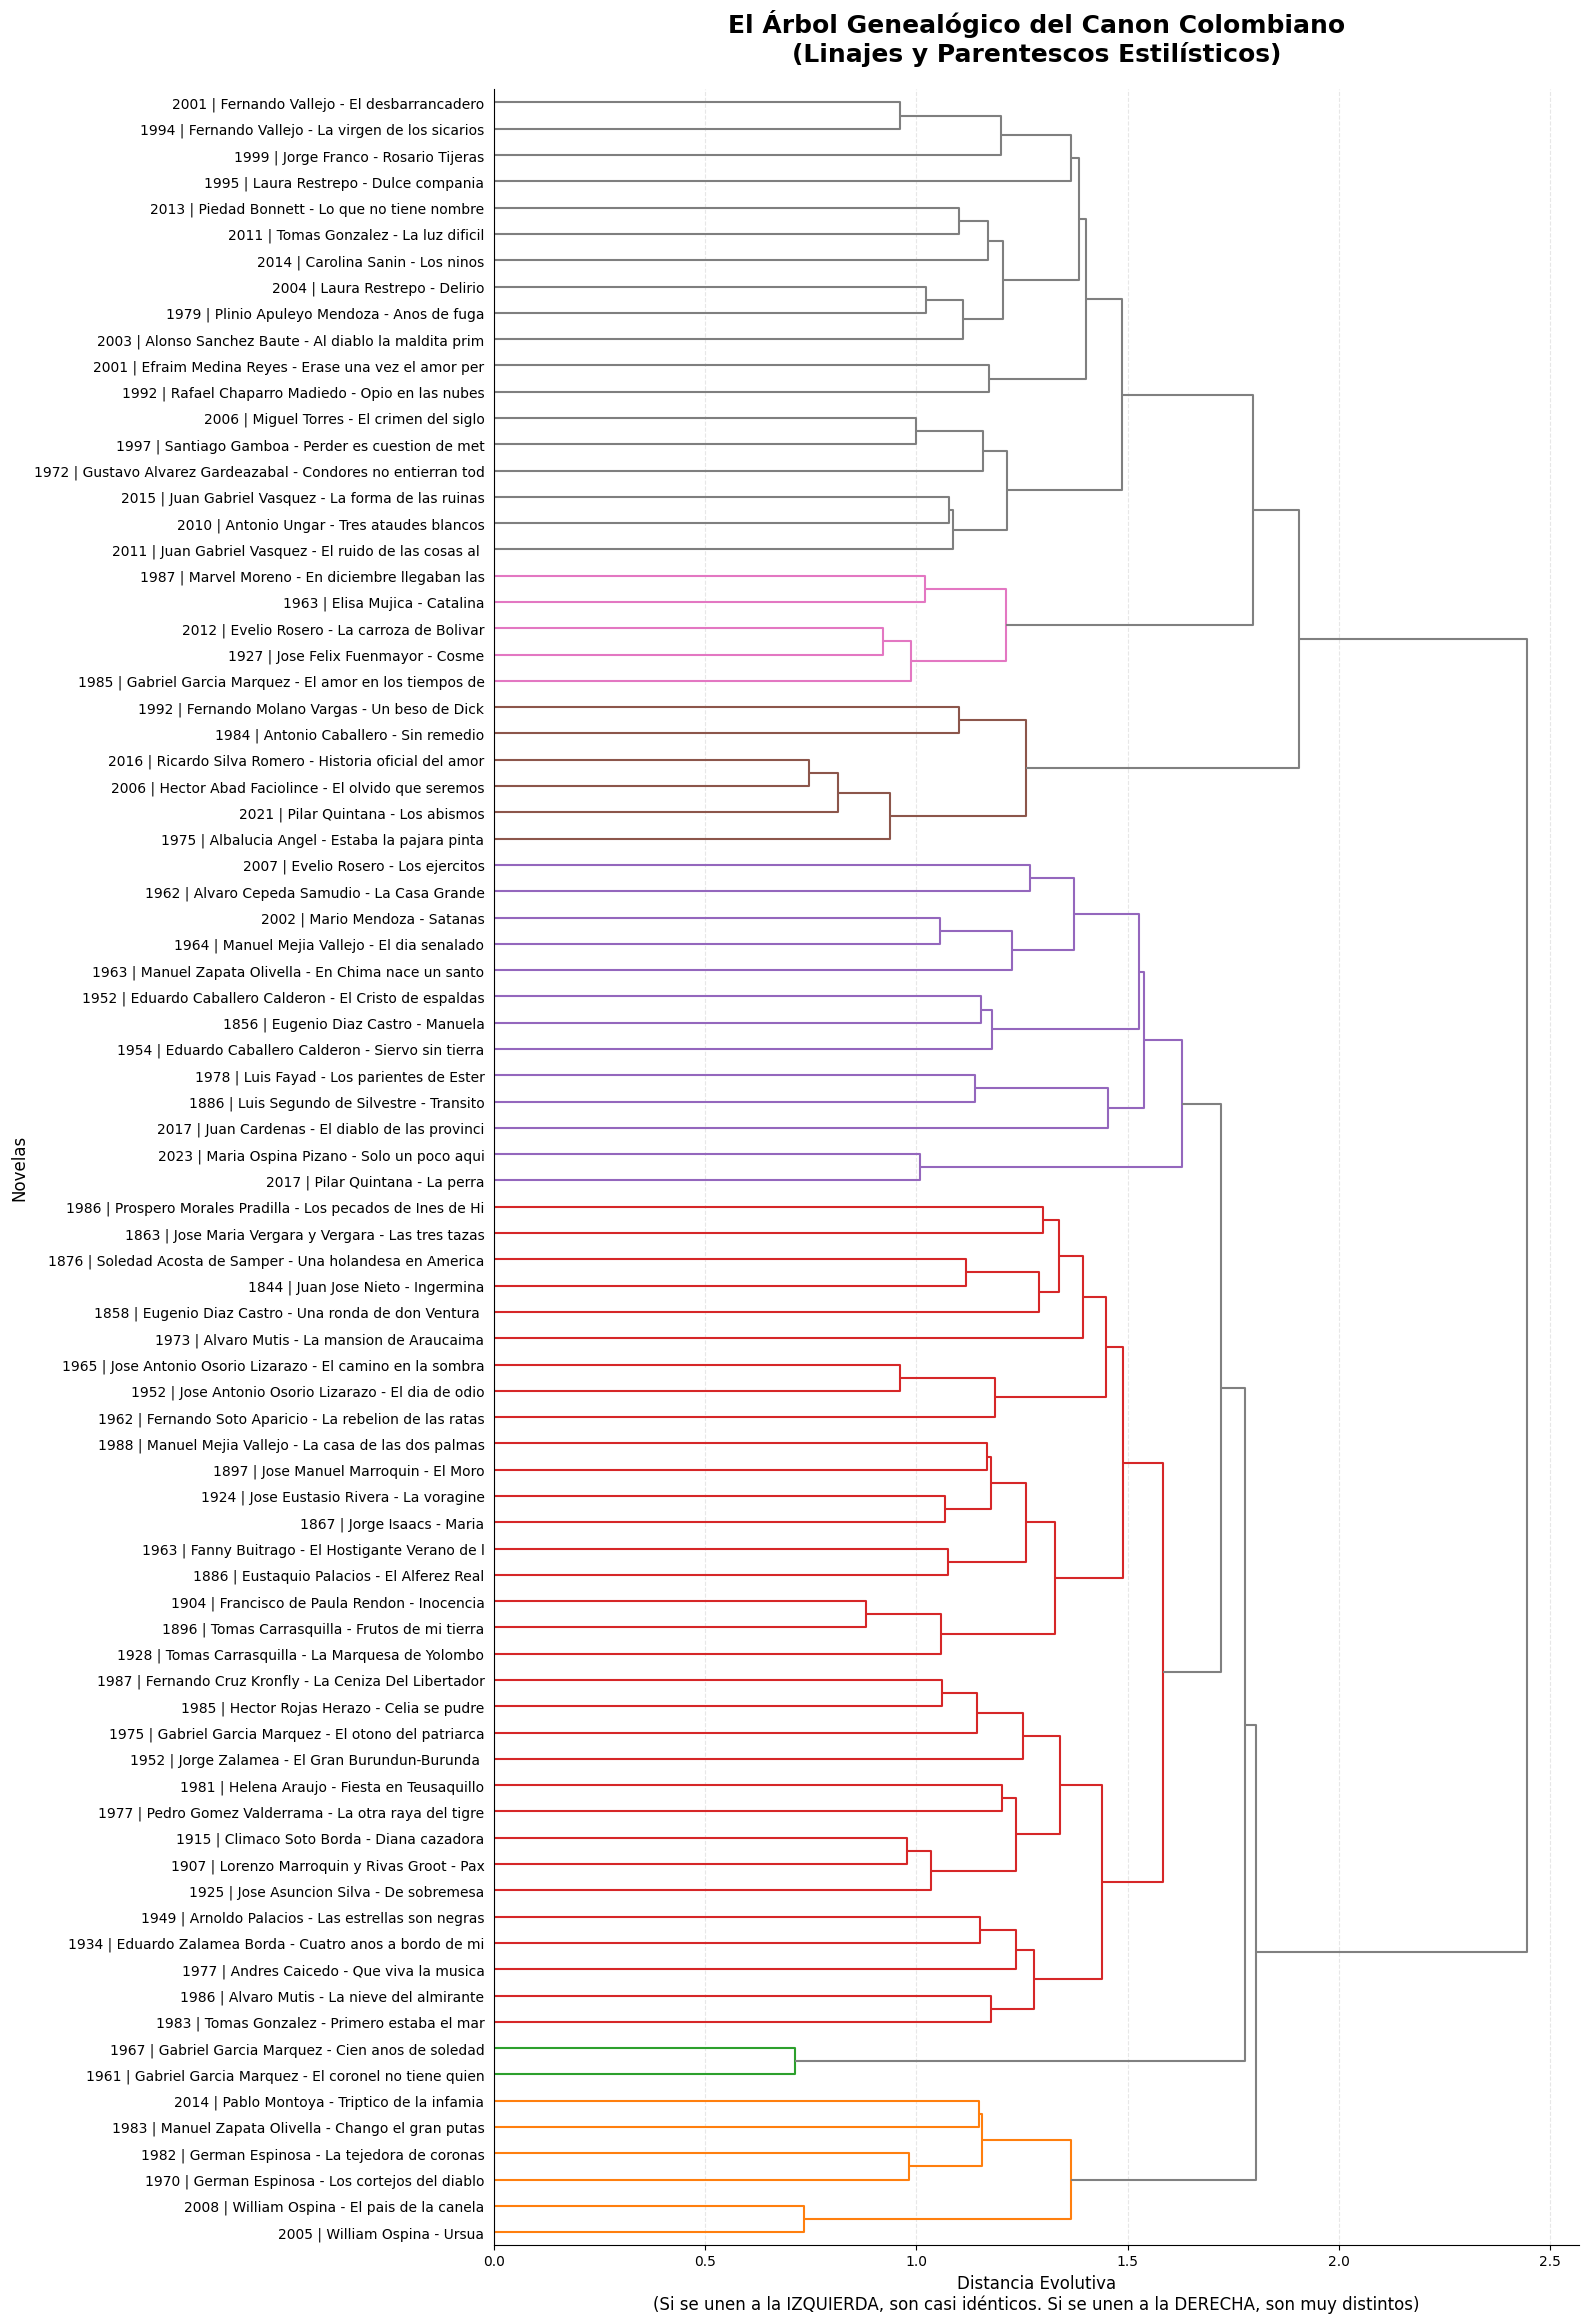


¡Árbol creado!


In [12]:
import os
import spacy
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage

print("1. Cargando Spacy...")
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
nlp.max_length = 3000000 

RUTA_TEXTOS = "Textos" 
corpus = []
etiquetas = []

print("2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos y Verbos)...")
for archivo in sorted(os.listdir(RUTA_TEXTOS)):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
            texto = f.read()

        doc = nlp(texto)
        
        # El genoma literario
        palabras = [
            token.lemma_.lower() for token in doc 
            if token.pos_ in ["NOUN", "ADJ", "VERB"] 
            and not token.is_stop 
            and len(token) > 2
        ]
        
        corpus.append(" ".join(palabras))
        
        # "Año | Autor - Título"
        partes = archivo.replace(".txt", "").split("_")
        anio = partes[0] if partes[0].isdigit() else "????"
        autor = partes[1].strip() if len(partes) > 1 else "Desconocido"
        titulo = partes[2].strip() if len(partes) > 2 else archivo
        
        etiquetas.append(f"{anio} | {autor} - {titulo[:25]}")
        
        print(f"ADN extraído: {titulo[:20]}...")

print("3. Calculando distancias evolutivas (Matriz TF-IDF)...")
# min_df=2 ignora palabras que solo aparecen en 1 libro (mutaciones raras)
# max_df=0.8 ignora palabras que están en el 80% de los libros (palabras demasiado comunes)
vectorizer = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.8)
matriz_tfidf = vectorizer.fit_transform(corpus)

print("4. Creando el Árbol Genealógico (Clustering de Ward)...")
# linkage calcula quién se parece más a quién para ir uniendo las ramas
Z = linkage(matriz_tfidf.toarray(), method='ward', metric='euclidean')

print("5. Dibujando el Dendrograma...")
plt.figure(figsize=(14, 28)) 
dendro = dendrogram(
    Z,
    labels=etiquetas,
    orientation='right',
    leaf_font_size=10,
    color_threshold=None, # Deja que Python pinte las grandes ramas automáticamente
    above_threshold_color='gray'
)

plt.title("El Árbol Genealógico del Canon Colombiano\n(Linajes y Parentescos Estilísticos)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Distancia Evolutiva\n(Si se unen a la IZQUIERDA, son casi idénticos. Si se unen a la DERECHA, son muy distintos)", fontsize=12)
plt.ylabel("Novelas", fontsize=12)

# Un poco de estilo para facilitar la lectura
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig("Dendrograma_Arbol_Canon.svg", format="svg", bbox_inches="tight")
plt.show()

print("\n¡Árbol creado!")

Cargando modelo spaCy...
Iniciando análisis de Acción (Verbos) vs. Descripción (Adjetivos)...


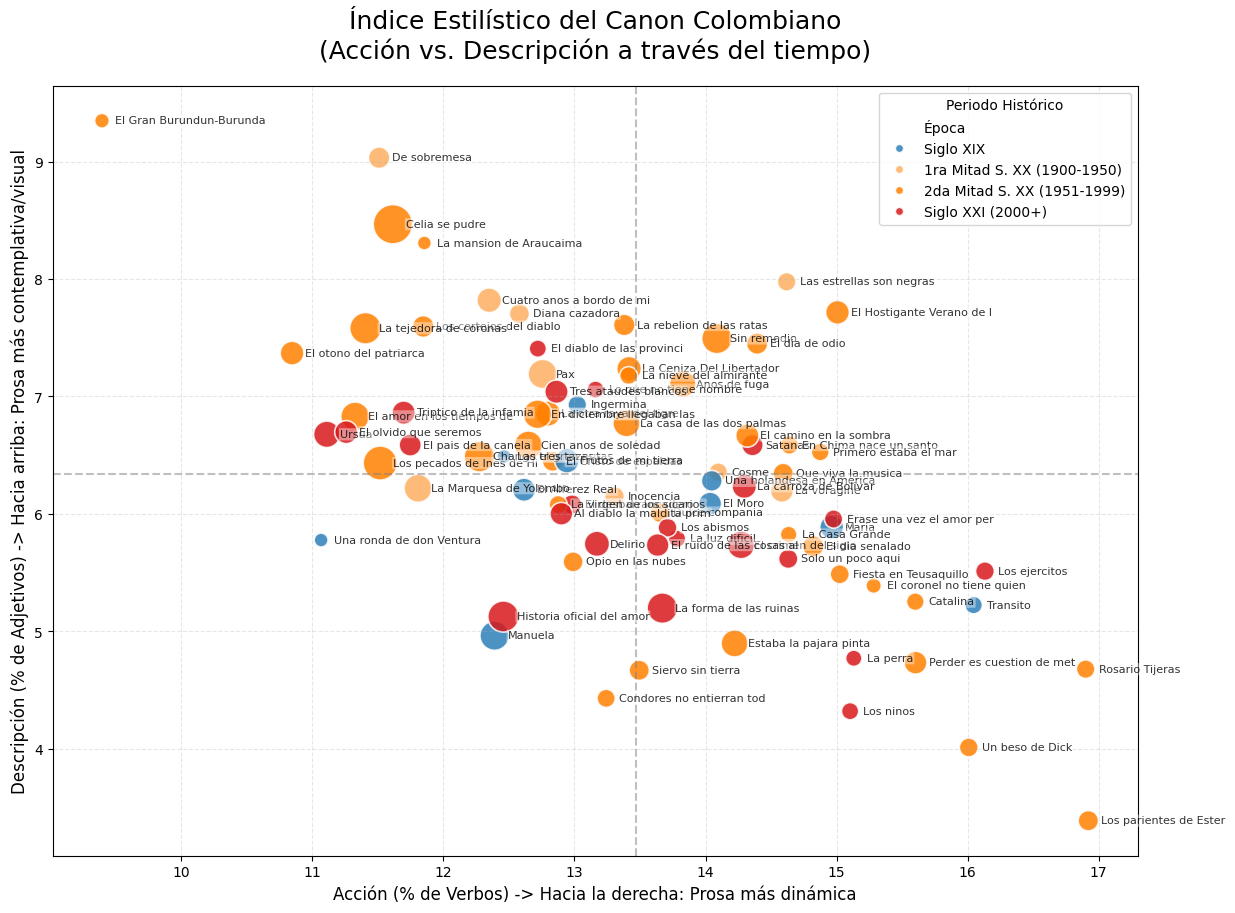


¡Gráfico exportado!


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import matplotlib

# =========================================================
# 0. Configuración para Illustrator (Texto editable)
# =========================================================
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# =========================================================
# 1. Función para categorizar épocas
# =========================================================
def categorizar_epoca(anio):
    if anio <= 1899:
        return "Siglo XIX"
    elif 1900 <= anio <= 1950:
        return "1ra Mitad S. XX (1900-1950)"
    elif 1951 <= anio <= 1999:
        return "2da Mitad S. XX (1951-1999)"
    else:
        return "Siglo XXI (2000+)"

# =========================================================
# 2. Cargar modelo NLP y procesar textos
# =========================================================
print("Cargando modelo spaCy...")
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
nlp.max_length = 3000000 

RUTA_TEXTOS = "Textos"
datos_accion = []

print("Iniciando análisis de Acción (Verbos) vs. Descripción (Adjetivos)...")

for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        ruta_completa = os.path.join(RUTA_TEXTOS, archivo)
        
        with open(ruta_completa, 'r', encoding='utf-8') as f:
            texto = f.read()
            
        doc = nlp(texto)
        
        total_palabras = 0
        verbos = 0
        adjetivos = 0
        
        # Etiquetado gramatical
        for token in doc:
            if not token.is_punct and not token.is_space and not token.like_num:
                total_palabras += 1
                if token.pos_ == "VERB":
                    verbos += 1
                elif token.pos_ == "ADJ":
                    adjetivos += 1
                    
        if total_palabras > 0:
            pct_verbos = (verbos / total_palabras) * 100
            pct_adjetivos = (adjetivos / total_palabras) * 100
        else:
            pct_verbos = 0
            pct_adjetivos = 0
            
        partes = archivo.replace(".txt", "").split("_")
        anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 0
        titulo = partes[2].strip() if len(partes) > 2 else archivo.replace(".txt", "")

        datos_accion.append({
            "Año": anio,
            "Época": categorizar_epoca(anio),
            "Título": titulo,
            "%_Verbos": pct_verbos,
            "%_Adjetivos": pct_adjetivos,
            "Total_Palabras": total_palabras
        })

df_accion = pd.DataFrame(datos_accion)
df_accion = df_accion[df_accion["Año"] > 1800] 

# =========================================================
# 3. Visualización Estilística (Categórica)
# =========================================================
paleta = {
    "Siglo XIX": "#2c7fb8",                   
    "1ra Mitad S. XX (1900-1950)": "#fdae61", 
    "2da Mitad S. XX (1951-1999)": "#ff8000", 
    "Siglo XXI (2000+)": "#d7191c"            
}

plt.figure(figsize=(14, 10))

ax = sns.scatterplot(
    data=df_accion,
    x="%_Verbos",
    y="%_Adjetivos",
    hue="Época",
    hue_order=["Siglo XIX", "1ra Mitad S. XX (1900-1950)", "2da Mitad S. XX (1951-1999)", "Siglo XXI (2000+)"],
    palette=paleta,
    size="Total_Palabras",
    sizes=(100, 800), 
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

promedio_verbos = df_accion["%_Verbos"].mean()
promedio_adjetivos = df_accion["%_Adjetivos"].mean()
plt.axvline(promedio_verbos, color='grey', linestyle='--', alpha=0.5, label="Promedio Verbos")
plt.axhline(promedio_adjetivos, color='grey', linestyle='--', alpha=0.5, label="Promedio Adjetivos")

plt.title("Índice Estilístico del Canon Colombiano\n(Acción vs. Descripción a través del tiempo)", fontsize=18, pad=20)
plt.xlabel("Acción (% de Verbos) -> Hacia la derecha: Prosa más dinámica", fontsize=12)
plt.ylabel("Descripción (% de Adjetivos) -> Hacia arriba: Prosa más contemplativa/visual", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

h, l = ax.get_legend_handles_labels()
epoca_index = l.index("Época") if "Época" in l else 0
plt.legend(h[epoca_index:epoca_index+5], l[epoca_index:epoca_index+5], title="Periodo Histórico", fontsize=10, loc='upper right')

# =========================================================
# 4. Etiquetado Completo (Para limpiar en Illustrator)
# =========================================================
for i in range(len(df_accion)):
    x = df_accion["%_Verbos"].iloc[i]
    y = df_accion["%_Adjetivos"].iloc[i]
    titulo = df_accion["Título"].iloc[i]
    
    plt.text(x + 0.1, y, titulo[:25], fontsize=8, alpha=0.8, va='center',
             bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.1'))

plt.savefig("Accion_vs_Descripcion_Categorico_Completo.pdf", format="pdf", bbox_inches="tight")
plt.show()

# =========================================================
# 5. Reporte de Consola
# =========================================================
print("\n¡Gráfico exportado!")

In [14]:
df_accion.to_csv("resultados_spacy.csv", index=False)

1. Cargando spaCy...
2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos, Verbos)...
Leído: Ingermina
Leído: Manuela
Leído: Una ronda de don Ven
Leído: Las tres tazas
Leído: Maria
Leído: Una holandesa en Ame
Leído: El Alferez Real
Leído: Transito
Leído: Frutos de mi tierra
Leído: El Moro
Leído: Inocencia
Leído: Pax
Leído: Diana cazadora
Leído: La voragine
Leído: De sobremesa
Leído: Cosme
Leído: La Marquesa de Yolom
Leído: Cuatro anos a bordo 
Leído: Las estrellas son ne
Leído: El Cristo de espalda
Leído: El Gran Burundun-Bur
Leído: El dia de odio
Leído: Siervo sin tierra
Leído: El coronel no tiene 
Leído: La Casa Grande
Leído: La rebelion de las r
Leído: Catalina
Leído: El Hostigante Verano
Leído: En Chima nace un san
Leído: El dia senalado
Leído: El camino en la somb
Leído: Cien anos de soledad
Leído: Los cortejos del dia
Leído: Condores no entierra
Leído: La mansion de Arauca
Leído: Estaba la pajara pin
Leído: El otono del patriar
Leído: Que viva la musica
Leído: La otra raya

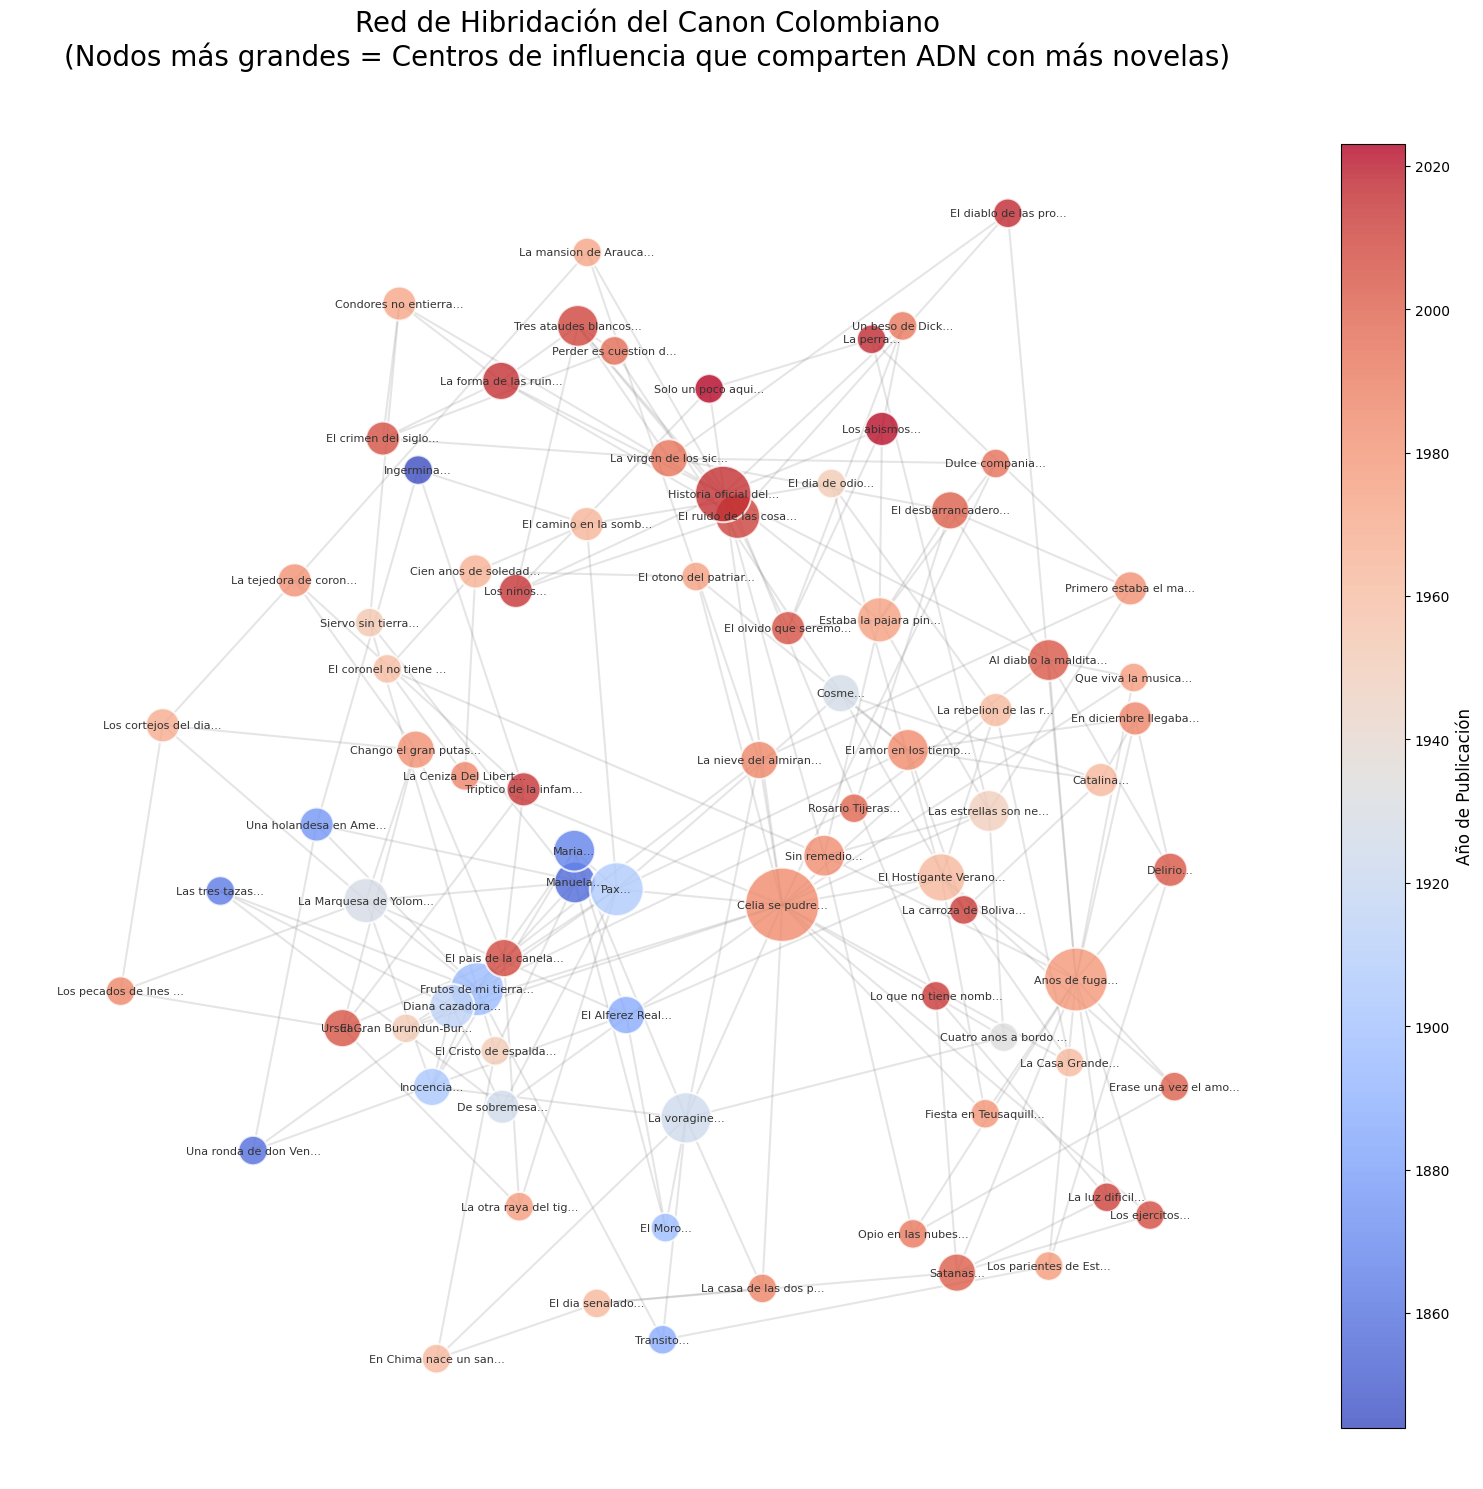


LOS HUBS:
- Celia se pudre... (19 conexiones estilísticas)
- Anos de fuga... (14 conexiones estilísticas)
- Historia oficial del... (11 conexiones estilísticas)
- Frutos de mi tierra... (10 conexiones estilísticas)
- Pax... (10 conexiones estilísticas)


In [17]:
import os
import spacy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("1. Cargando spaCy...")
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
nlp.max_length = 3000000 

RUTA_TEXTOS = "Textos" 
corpus = []
titulos_cortos = []
anios = []

print("2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos, Verbos)...")
archivos_validos = [a for a in sorted(os.listdir(RUTA_TEXTOS)) if a.endswith(".txt") and not a.startswith(".")]

for archivo in archivos_validos:
    with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
        texto = f.read()

    doc = nlp(texto)
    palabras = [
        token.lemma_.lower() for token in doc 
        if token.pos_ in ["NOUN", "ADJ", "VERB"] and not token.is_stop and len(token) > 2
    ]
    corpus.append(" ".join(palabras))
    
    partes = archivo.replace(".txt", "").split("_")
    anio = int(partes[0]) if partes[0].isdigit() else 1900
    titulo = partes[2].strip() if len(partes) > 2 else archivo
    
    titulos_cortos.append(titulo[:20] + "...") # Recortamos para que el mapa sea legible
    anios.append(anio)
    
    print(f"Leído: {titulo[:20]}")

print("\n3. Calculando la Similitud del Coseno...")
vectorizer = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.8)
matriz_tfidf = vectorizer.fit_transform(corpus)
matriz_similitud = cosine_similarity(matriz_tfidf)

print("4. Construyendo la Red Literaria (Grafo de red)...")
G = nx.Graph()

# Añadir los nodos (Las novelas)
for i in range(len(titulos_cortos)):
    G.add_node(i, label=titulos_cortos[i], year=anios[i])

# Añadir las aristas
# Cada libro se conecta con sus 3 libros más similares
for i in range(len(titulos_cortos)):
    # Obtenemos los índices de las novelas más similares (excluyendo la novela misma)
    similares = np.argsort(matriz_similitud[i])[-4:-1] 
    
    for j in similares:
        peso = matriz_similitud[i][j]
        G.add_edge(i, j, weight=peso)

# Calcular el grado de cada nodo para definir su tamaño
grados = dict(G.degree())
tamanos_nodos = [v * 150 for k, v in grados.items()] # Multiplicador visual

print("5. Dibujando el Universo del Canon...")
plt.figure(figsize=(18, 18))

# El layout spring permite los nodos que comparten conexiones se atraigan
pos = nx.spring_layout(G, k=0.45, iterations=60, seed=42)

# Dibujar las aristas
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color="gray", width=1.5)

# Dibujar los nodos con color por siglo
scatter = nx.draw_networkx_nodes(
    G, pos, 
    node_size=tamanos_nodos, 
    node_color=anios, 
    cmap="coolwarm", 
    alpha=0.8, 
    edgecolors="white", 
    linewidths=1.5
)

# Dibujar los títulos
labels = {i: titulos_cortos[i] for i in range(len(titulos_cortos))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family="sans-serif", font_color="#333333")

# Tipografía
plt.title("Red de Hibridación del Canon Colombiano\n(Nodos más grandes = Centros de influencia que comparten ADN con más novelas)", fontsize=20, pad=20)
cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
cbar.set_label("Año de Publicación", fontsize=12)

plt.axis("off") 
plt.savefig("Grafo_Red_Literaria.svg", format="svg", bbox_inches="tight")
plt.show()

# Encontrar los Hubs
print("\nLOS HUBS:")
top_hubs = sorted(grados.items(), key=lambda x: x[1], reverse=True)[:5]
for nodo, conexiones in top_hubs:
    print(f"- {titulos_cortos[nodo]} ({conexiones} conexiones estilísticas)")

In [ ]:
# 1. Nos aseguramos de que la herramienta esté instalada en ESTE entorno
%pip install nbconvert

# 2. Obligamos a Python a usar su propio Jupyter interno para convertir el archivo
!python -m jupyter nbconvert --to html riqueza_lexica.ipynb


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] Converting notebook riqueza_lexica.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 29 image(s).
[NbConvertApp] Writing 8823613 bytes to riqueza_lexica.html


4. Construir la Red Literaria (Grafo Dirigido)
5. Dibujando el Universo del Canon


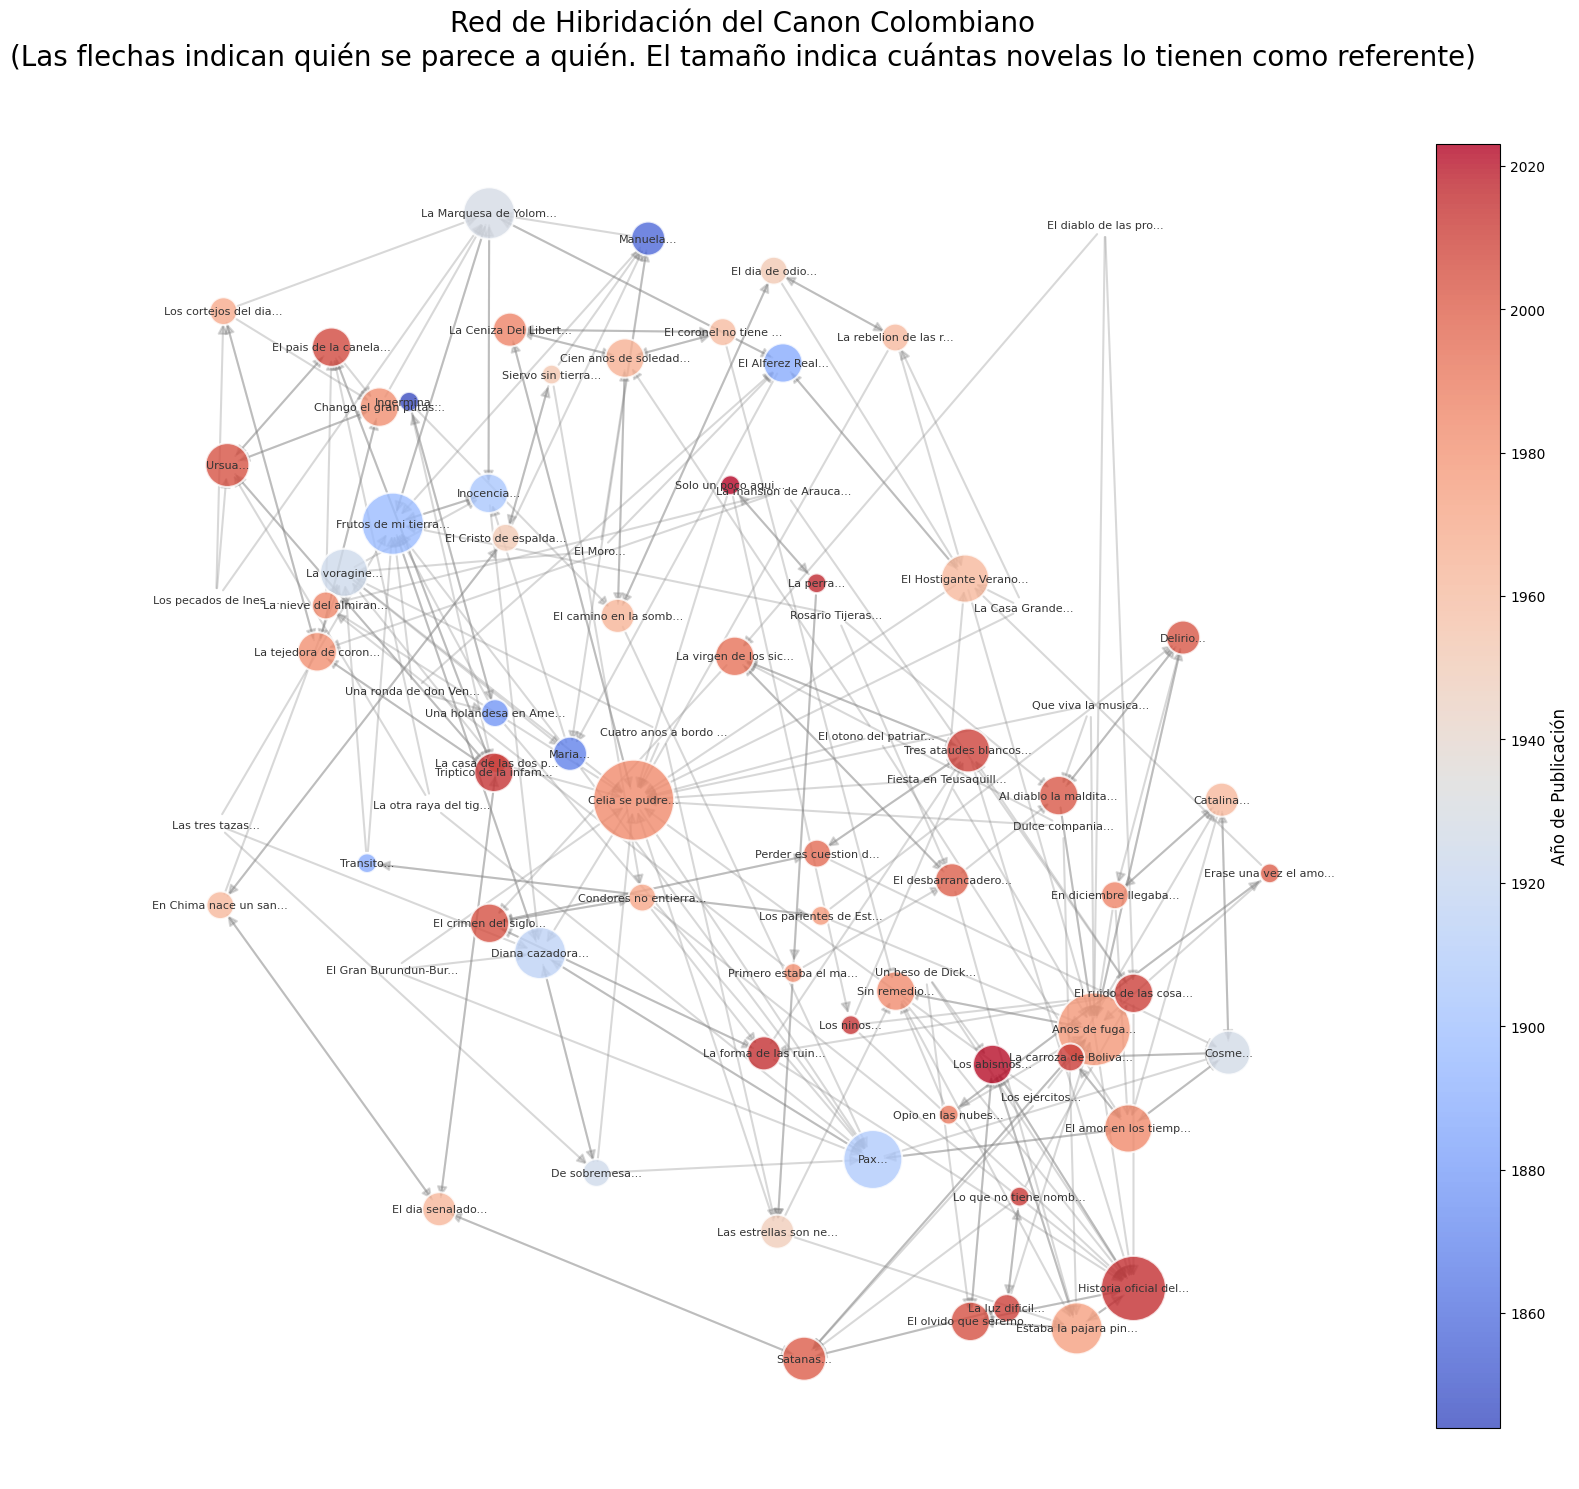


6. Exportando datos para Gephi
¡Exportación exitosa! Abre el archivo 'Red_Canon_Colombiano.gexf' directamente en Gephi.

👑 LOS GRANDES 'HUBS' (Las novelas más imitadas / citadas léxicamente):
- Celia se pudre... (Recibe 17 conexiones entrantes)
- Anos de fuga... (Recibe 14 conexiones entrantes)
- Historia oficial del... (Recibe 11 conexiones entrantes)
- Frutos de mi tierra... (Recibe 10 conexiones entrantes)
- Pax... (Recibe 9 conexiones entrantes)


In [18]:
print("4. Construir la Red Literaria (Grafo Dirigido)")
# Usar DiGraph para que las conexiones tengan flecha de origen y destino
G = nx.DiGraph() 

# Añadir los nodos con sus atributos para Gephi
for i in range(len(titulos_cortos)):
    # Convertir el año a int estándar de Python para evitar errores de exportación
    anio_gephi = int(anios[i]) 
    G.add_node(i, label=titulos_cortos[i], year=anio_gephi)

# Añadir las aristas (Las conexiones dirigidas)
for i in range(len(titulos_cortos)):
    # Obtener los índices de las 3 novelas más similares
    similares = np.argsort(matriz_similitud[i])[-4:-1] 
    
    for j in similares:
        # Convertir el peso a float estándar de Python para Gephi
        peso = float(matriz_similitud[i][j]) 
        if peso > 0:
            G.add_edge(i, j, weight=peso)

# Calcular el grado de cada nodo 
# Usar in_degree para definir su tamaño
grados_entrada = dict(G.in_degree())
tamanos_nodos = [v * 200 for k, v in grados_entrada.items()] 

print("5. Dibujando el Universo del Canon")
plt.figure(figsize=(18, 18))
pos = nx.spring_layout(G, k=0.45, iterations=60, seed=42)

# Dibujar las conexiones 
nx.draw_networkx_edges(
    G, pos, 
    alpha=0.3, 
    edge_color="gray", 
    width=1.5, 
    arrows=True, 
    arrowsize=15 # Tamaño de la punta de la flecha
)

scatter = nx.draw_networkx_nodes(
    G, pos, 
    node_size=tamanos_nodos, 
    node_color=anios, 
    cmap="coolwarm", 
    alpha=0.8, 
    edgecolors="white", 
    linewidths=1.5
)

labels = {i: titulos_cortos[i] for i in range(len(titulos_cortos))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family="sans-serif", font_color="#333333")

plt.title("Red de Hibridación del Canon Colombiano\n(Las flechas indican quién se parece a quién. El tamaño indica cuántas novelas lo tienen como referente)", fontsize=20, pad=20)
cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
cbar.set_label("Año de Publicación", fontsize=12)

plt.axis("off")
plt.savefig("Grafo_Red_Literaria_Dirigido.svg", format="svg", bbox_inches="tight")
plt.show()

# =========================================================
# 6. EXPORTAR A GEPHI
# =========================================================
print("\n6. Exportando datos para Gephi")
archivo_gexf = "Red_Canon_Colombiano.gexf"
nx.write_gexf(G, archivo_gexf)
print(f"¡Exportación exitosa! Abre el archivo '{archivo_gexf}' directamente en Gephi.")

print("\n👑 LOS GRANDES 'HUBS' (Las novelas más imitadas / citadas léxicamente):")
top_hubs = sorted(grados_entrada.items(), key=lambda x: x[1], reverse=True)[:5]
for nodo, conexiones in top_hubs:
    print(f"- {titulos_cortos[nodo]} (Recibe {conexiones} conexiones entrantes)")

In [20]:
import pandas as pd
import numpy as np

print("\n7. EXPORTANDO 'RAYOS X' LÉXICOS DE TODA LA RED A CSV...")
print("================================================================")

# Obtener la lista de las palabras y la matriz densa
nombres_palabras = vectorizer.get_feature_names_out()
matriz_densa = matriz_tfidf.toarray()

# Guardar todas las filas del archivo Excel/CSV
datos_conexiones = []

# Recorrer las novelas del canon
for i in range(len(titulos_cortos)):
    titulo_origen = titulos_cortos[i]
    anio_origen = anios[i]
    
    # Obtener las 3 novelas más similares de toda la base de datos
    similares = np.argsort(matriz_similitud[i])[-4:-1]
    
    # Invertir el orden para que la #1 más parecida salga primero
    similares = similares[::-1] 
    
    for ranking, j in enumerate(similares):
        titulo_destino = titulos_cortos[j]
        anio_destino = anios[j]
        similitud = float(matriz_similitud[i][j])
        
        # MULTIPLICACIÓN DE VECTORES (El ADN compartido)
        pesos_compartidos = matriz_densa[i] * matriz_densa[j]
        
        # Extraer las 15 palabras con más peso en esta conexión
        indices_top = pesos_compartidos.argsort()[::-1][:15]
        
        palabras_puente = []
        for idx in indices_top:
            if pesos_compartidos[idx] > 0:
                palabras_puente.append(nombres_palabras[idx])
                
        # Guardar los datos de esta conexión en la lista
        datos_conexiones.append({
            "Novela": titulo_origen,
            "Anio_Novela": anio_origen,
            "Ranking_Afinidad": ranking + 1,  # 1, 2 o 3
            "Se_Parece_A": titulo_destino,
            "Anio_Destino": anio_destino,
            "Fuerza_Similitud": round(similitud, 4),
            "Palabras_Compartidas": ", ".join(palabras_puente)
        })

# Convertir la lista en un DataFrame de Pandas
df_rayos_x = pd.DataFrame(datos_conexiones)

# Exportar a CSV 
nombre_archivo_csv = "Rayos_X_Red_Canon.csv"
df_rayos_x.to_csv(nombre_archivo_csv, index=False, encoding="utf-8-sig")

print(f"Se ha generado el archivo: '{nombre_archivo_csv}'")
print(f"Total de conexiones analizadas y exportadas: {len(df_rayos_x)}")


7. EXPORTANDO 'RAYOS X' LÉXICOS DE TODA LA RED A CSV...
Se ha generado el archivo: 'Rayos_X_Red_Canon.csv'
Total de conexiones analizadas y exportadas: 246


4. Contruyendo la Red Genealógica
5. Dibujando el Árbol Genealógico


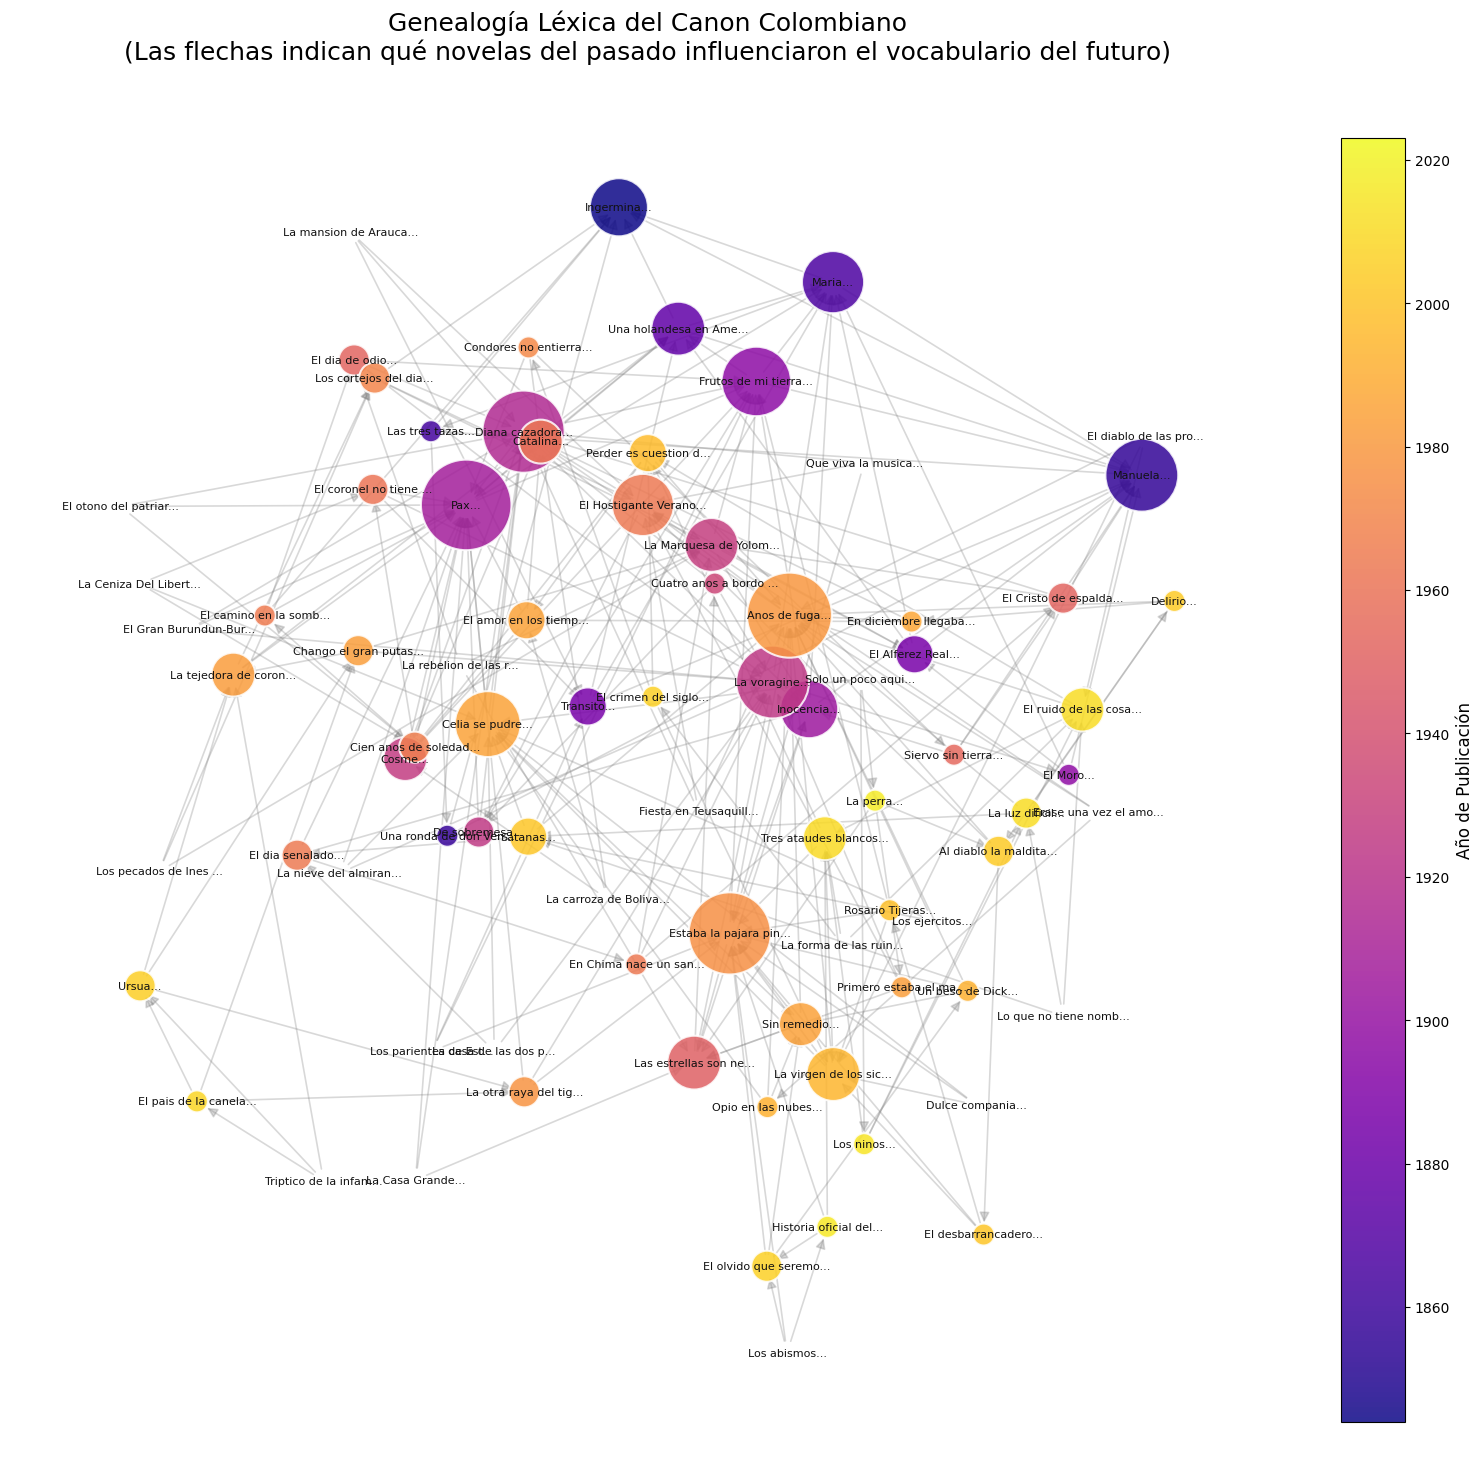


 6. Exportando datos para Gephi

LOS ANCESTROS (Las novelas que más influenciaron al futuro):
- Pax... (Influyó directamente en 17 novelas posteriores)
- Anos de fuga... (Influyó directamente en 15 novelas posteriores)
- Diana cazadora... (Influyó directamente en 14 novelas posteriores)
- Estaba la pajara pin... (Influyó directamente en 14 novelas posteriores)
- Manuela... (Influyó directamente en 11 novelas posteriores)


In [19]:
print("4. Contruyendo la Red Genealógica")
G = nx.DiGraph() 

# Añadir los nodos
for i in range(len(titulos_cortos)):
    G.add_node(i, label=titulos_cortos[i], year=int(anios[i]))

# Añadir las aristas (Buscando a los ancestros)
for i in range(len(titulos_cortos)):
    candidatos_pasado = []
    
    # Filtrar la matriz de similitud
    for j in range(len(titulos_cortos)):
        if anios[j] < anios[i]: # Solo años anteriores
            peso = float(matriz_similitud[i][j])
            if peso > 0:
                candidatos_pasado.append((j, peso))
    
    # Ordenar los ancestros del más similar al menos similar
    candidatos_pasado.sort(key=lambda x: x[1], reverse=True)
    
    # La novela elige a sus 3 mayores influencias del pasado
    top_3_ancestros = candidatos_pasado[:3]
    
    for j, peso in top_3_ancestros:
        G.add_edge(i, j, weight=peso)

# Calcular la importancia 
grados_entrada = dict(G.in_degree())
# Aumentar el multiplicador visual para que los ancestros sean mas grandes
tamanos_nodos = [v * 250 for k, v in grados_entrada.items()] 

# =========================================================
# 5. VISUALIZACIÓN EN PYTHON
# =========================================================
print("5. Dibujando el Árbol Genealógico")
plt.figure(figsize=(18, 18))

pos = nx.spring_layout(G, k=0.55, iterations=80, seed=42)

# Dibujar conexiones con flechas
nx.draw_networkx_edges(
    G, pos, 
    alpha=0.3, 
    edge_color="gray", 
    width=1.2, 
    arrows=True, 
    arrowsize=15 # Tamaño de la punta de la flecha
)

# Dibujar los Nodos, coloreados por época
scatter = nx.draw_networkx_nodes(
    G, pos, 
    node_size=tamanos_nodos, 
    node_color=anios, 
    cmap="plasma", 
    alpha=0.85, 
    edgecolors="white", 
    linewidths=1.5
)

# Dibujar los títulos
labels = {i: titulos_cortos[i] for i in range(len(titulos_cortos))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family="sans-serif", font_color="#111111")

plt.title("Genealogía Léxica del Canon Colombiano\n(Las flechas indican qué novelas del pasado influenciaron el vocabulario del futuro)", fontsize=18, pad=20)
cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
cbar.set_label("Año de Publicación", fontsize=12)

plt.axis("off") 
plt.savefig("Grafo_Genealogia_Canon.svg", format="svg", bbox_inches="tight")
plt.show()

# =========================================================
# 6. EXPORTACIÓN A GEPHI Y RESULTADOS EN CONSOLA
# =========================================================
print("\n 6. Exportando datos para Gephi")
archivo_gexf = "Genealogia_Canon_Colombiano.gexf"
nx.write_gexf(G, archivo_gexf)

print("\nLOS ANCESTROS (Las novelas que más influenciaron al futuro):")
top_ancestros = sorted(grados_entrada.items(), key=lambda x: x[1], reverse=True)[:5]
for nodo, conexiones in top_ancestros:
    print(f"- {titulos_cortos[nodo]} (Influyó directamente en {conexiones} novelas posteriores)")

In [21]:
import pandas as pd
import networkx as nx

print("Calculando medidas de centralidad topológica del Canon")

# 1. CENTRALIDAD DE GRADO DE ENTRADA (In-Degree Centrality)
# ¿Quién es el más influyente (el ancestro más citado)?
in_degree = nx.in_degree_centrality(G)

# 2. CENTRALIDAD DE INTERMEDIACIÓN (Betweenness Centrality)
# ¿Quién es el puente generacional?
betweenness = nx.betweenness_centrality(G)

# 3. CENTRALIDAD DE CERCANÍA (Closeness Centrality)
# Qué tan "rápido" o directamente se puede llegar desde este libro a todos los demás.
closeness = nx.closeness_centrality(G)

# Consolidar los datos en un DataFrame
datos_topologia = []
for nodo in G.nodes():
    datos_topologia.append({
        "Libro": G.nodes[nodo]['label'],
        "Año": G.nodes[nodo]['year'],
        "Grado Entrada (Influencia)": in_degree[nodo],
        "Intermediación (Puente)": betweenness[nodo],
        "Cercanía": closeness[nodo]
    })

df_topologia = pd.DataFrame(datos_topologia)

# Mostrar los resultados (Los 5 más altos en cada categoría)

print("LOS MAYORES ANCESTROS (Mayor Grado de Entrada):")
print("Las obras más imitadas/referenciadas léxicamente por la posteridad.")
print(df_topologia.sort_values(by="Grado Entrada (Influencia)", ascending=False)[['Libro', 'Año', 'Grado Entrada (Influencia)']].head(5).to_string(index=False))
print("-" * 50)

print("\nLOS GRANDES PUENTES (Mayor Intermediación):")
print("Las novelas que sirven de bisagra estilística entre el pasado y el futuro.")
print(df_topologia.sort_values(by="Intermediación (Puente)", ascending=False)[['Libro', 'Año', 'Intermediación (Puente)']].head(5).to_string(index=False))
print("-" * 50)

Calculando medidas de centralidad topológica del Canon
LOS MAYORES ANCESTROS (Mayor Grado de Entrada):
Las obras más imitadas/referenciadas léxicamente por la posteridad.
                  Libro  Año  Grado Entrada (Influencia)
                 Pax... 1907                    0.209877
        Anos de fuga... 1979                    0.185185
Estaba la pajara pin... 1975                    0.172840
      Diana cazadora... 1915                    0.172840
         La voragine... 1924                    0.135802
--------------------------------------------------

LOS GRANDES PUENTES (Mayor Intermediación):
Las novelas que sirven de bisagra estilística entre el pasado y el futuro.
                  Libro  Año  Intermediación (Puente)
Estaba la pajara pin... 1975                 0.033568
               Maria... 1867                 0.028868
        Anos de fuga... 1979                 0.025041
Las estrellas son ne... 1949                 0.021673
                 Pax... 1907                 0

In [22]:
import os
import spacy
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("1. Cargando spaCy...")
nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])
nlp.max_length = 3000000 

RUTA_TEXTOS = "Textos" 
corpus = []
titulos_cortos = []
anios = []

print("2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos, Verbos)")
archivos_validos = [a for a in sorted(os.listdir(RUTA_TEXTOS)) if a.endswith(".txt") and not a.startswith(".")]

for archivo in archivos_validos:
    with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
        texto = f.read()

    doc = nlp(texto)
    palabras = [
        token.lemma_.lower() for token in doc 
        if token.pos_ in ["NOUN", "ADJ", "VERB"] and not token.is_stop and len(token) > 2
    ]
    corpus.append(" ".join(palabras))
    
    partes = archivo.replace(".txt", "").split("_")
    anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 1900
    titulo = partes[2].strip() if len(partes) > 2 else archivo.replace(".txt", "")
    
    titulos_cortos.append(titulo[:20] + "...") # Recortamos para visualización
    anios.append(anio)
    
    print("Leído: {titulo[:20]}")

print("3. Calculando la Similitud del Coseno...")
vectorizer = TfidfVectorizer(max_features=2500, min_df=2, max_df=0.8)
matriz_tfidf = vectorizer.fit_transform(corpus)
matriz_similitud = cosine_similarity(matriz_tfidf)

print("4. Construyendo el Árbol Genealógico con conexiones solo hacia el pasado")
G = nx.DiGraph() # Grafo Dirigido

# Añadimos los nodos (Los libros)
for i in range(len(titulos_cortos)):
    G.add_node(i, label=titulos_cortos[i], year=int(anios[i]))

# Añadimos las aristas (Buscando a los ancestros)
for i in range(len(titulos_cortos)):
    candidatos_pasado = []
    
    # Comparamos la novela 'i' con todas las demás ('j')
    for j in range(len(titulos_cortos)):
        # LA REGLA DE ORO: La novela 'j' debe ser más antigua que la novela 'i'
        if anios[j] < anios[i]:
            peso = float(matriz_similitud[i][j])
            if peso > 0:
                candidatos_pasado.append((j, peso))
    
    # Ordenamos los candidatos del más similar al menos similar
    candidatos_pasado.sort(key=lambda x: x[1], reverse=True)
    
    # La novela 'i' elige a sus 3 mayores influencias del pasado
    top_3_ancestros = candidatos_pasado[:3]
    
    for j, peso in top_3_ancestros:
        G.add_edge(i, j, weight=peso)

# Calculamos la importancia (In-Degree = Cuántas novelas del futuro se basan en ti)
grados_entrada = dict(G.in_degree())
tamanos_nodos = [v * 200 for k, v in grados_entrada.items()] 

print("5. Dibujando vista previa...")
plt.figure(figsize=(16, 16))
pos = nx.spring_layout(G, k=0.6, iterations=80, seed=42)

# Flechas que apuntan de la novela nueva a la antigua
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray", width=1.2, arrows=True, arrowsize=15)

scatter = nx.draw_networkx_nodes(
    G, pos, 
    node_size=tamanos_nodos, 
    node_color=anios, 
    cmap="plasma", # Usamos plasma para diferenciar visualmente esta red de la anterior
    alpha=0.8, 
    edgecolors="white", 
    linewidths=1.5
)

labels = {i: titulos_cortos[i] for i in range(len(titulos_cortos))}
nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family="sans-serif", font_color="#333333")

plt.title("Genealogía Léxica del Canon Colombiano\n(Las novelas recientes se conectan con sus ancestros literarios)", fontsize=18, pad=20)
cbar = plt.colorbar(scatter, fraction=0.046, pad=0.04)
cbar.set_label("Año de Publicación", fontsize=12)
plt.axis("off")
plt.show()

# =========================================================
# 6. EXPORTACIÓN A GEPHI
# =========================================================
print("\n6. Exportando datos para Gephi")
archivo_gexf = "Genealogia_Canon_Colombiano.gexf"
nx.write_gexf(G, archivo_gexf)
print(f"¡Exportación exitosa!")

# Resultados en Consola
print("LOS GRANDES 'ANCESTROS' (Las novelas más influyentes para el futuro):")
top_ancestros = sorted(grados_entrada.items(), key=lambda x: x[1], reverse=True)[:5]
for nodo, conexiones in top_ancestros:
    print(f"- {titulos_cortos[nodo]} (Influyó directamente en {conexiones} novelas posteriores)")

1. Cargando spaCy...
2. Extrayendo el ADN de las novelas (Sustantivos, Adjetivos, Verbos)
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: {titulo[:20]}
Leído: 

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import networkx as nx

print("Calculando medidas de centralidad topológica del Canon...\n")

# 1. CENTRALIDAD DE GRADO DE ENTRADA (In-Degree Centrality)
in_degree = nx.in_degree_centrality(G)

# 2. CENTRALIDAD DE INTERMEDIACIÓN (Betweenness Centrality)
betweenness = nx.betweenness_centrality(G)

# 3. CENTRALIDAD DE CERCANÍA (Closeness Centrality)
closeness = nx.closeness_centrality(G)

# Consolidar los datos en un DataFrame
datos_topologia = []
for nodo in G.nodes():
    datos_topologia.append({
        "Libro": G.nodes[nodo]['label'],
        "Año": G.nodes[nodo]['year'],
        "Grado Entrada (Influencia)": in_degree[nodo],
        "Intermediación (Puente)": betweenness[nodo],
        "Cercanía": closeness[nodo]
    })

df_topologia = pd.DataFrame(datos_topologia)

# Mostrar los resultados (Los 5 más altos en cada categoría)

print("LOS MAYORES ANCESTROS (Mayor Grado de Entrada):")
print("Las obras más imitadas/referenciadas léxicamente por la posteridad.")
print(df_topologia.sort_values(by="Grado Entrada (Influencia)", ascending=False)[['Libro', 'Año', 'Grado Entrada (Influencia)']].head(5).to_string(index=False))
print("-" * 50)

print("\nLOS GRANDES PUENTES (Mayor Intermediación):")
print("Las novelas que sirven de bisagra estilística entre el pasado y el futuro.")
print(df_topologia.sort_values(by="Intermediación (Puente)", ascending=False)[['Libro', 'Año', 'Intermediación (Puente)']].head(5).to_string(index=False))
print("-" * 50)

📊 Calculando medidas de centralidad topológica del Canon...

🏆 LOS MAYORES ANCESTROS (Mayor Grado de Entrada):
Las obras más imitadas/referenciadas léxicamente por la posteridad.
                  Libro  Año  Grado Entrada (Influencia)
                 Pax... 1907                    0.209877
        Anos de fuga... 1979                    0.185185
      Diana cazadora... 1915                    0.172840
Estaba la pajara pin... 1975                    0.172840
         La voragine... 1924                    0.135802
--------------------------------------------------

🌉 LOS GRANDES PUENTES (Mayor Intermediación):
Las novelas que sirven de bisagra estilística entre el pasado y el futuro.
                  Libro  Año  Intermediación (Puente)
Estaba la pajara pin... 1975                 0.033996
        Anos de fuga... 1979                 0.025249
Las estrellas son ne... 1949                 0.021762
             Manuela... 1866                 0.017886
         La voragine... 1924        

In [ ]:
import networkx as nx
import pandas as pd

print("Calculando métricas topológicas\n")

# 1. PAGERANK LITERARIO (Evolución del Eigenvector para grafos dirigidos)
pagerank = nx.pagerank(G, weight='weight')

# 2. CENTRALIDAD DE EIGENVECTOR (Vector Propio)
try:
    eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')
except Exception as e:
    print("Nota: El Eigenvector no pudo converger. Se usará PageRank.")
    eigenvector = pagerank 

# 3. EXCENTRICIDAD (El centro vs. la periferia)
G_no_dirigido = G.to_undirected() # Quitar las flechas temporalmente para medir distancias
componente_principal = max(nx.connected_components(G_no_dirigido), key=len)
G_core = G_no_dirigido.subgraph(componente_principal)

excentricidad = nx.eccentricity(G_core)

# El Radio 
radio_canon = nx.radius(G_core)
# El Diámetro 
diametro_canon = nx.diameter(G_core)

# Consolidar los nuevos datos
datos_avanzados = []
for nodo in G.nodes():
    datos_avanzados.append({
        "Libro": G.nodes[nodo]['label'],
        "Año": G.nodes[nodo]['year'],
        "PageRank (Prestigio)": pagerank.get(nodo, 0),
        "Eigenvector": eigenvector.get(nodo, 0),
        "Excentricidad": excentricidad.get(nodo, "Periferia Aislada") 
    })

df_avanzado = pd.DataFrame(datos_avanzados)

print("LINAJE DE PRESTIGIO (Mayor PageRank / Eigenvector):")
print("No solo influyeron a muchos, sino que influyeron a los más conectados.")
print(df_avanzado.sort_values(by="PageRank (Prestigio)", ascending=False)[['Libro', 'Año', 'PageRank (Prestigio)']].head(5).to_string(index=False))
print("-" * 60)

centro_canon = [n for n in G_core.nodes() if excentricidad[n] == radio_canon]
periferia_canon = [n for n in G_core.nodes() if excentricidad[n] == diametro_canon]

print("EL NÚCLEO DEL CANON (Radio = {radio_canon}):")
print("Las novelas con menor excentricidad. Están a menor distancia de cualquier otro libro.")
for n in centro_canon[:5]:
    print(f"- {G.nodes[n]['label']}")
print("-" * 60)

print("LA EXTREMA PERIFERIA (Diámetro = {diametro_canon}):")
print("Los libros más excéntricos, en la periferia del universo literario, con el léxico más alejado del resto.")
for n in periferia_canon[:5]:
    print(f"- {G.nodes[n]['label']}")

📊 Calculando métricas topológicas avanzadas...

Nota: El Eigenvector no pudo converger. Se usará PageRank como sustituto ideal.
🥇 LINAJE DE PRESTIGIO (Mayor PageRank / Eigenvector):
No solo influyeron a muchos, sino que influyeron a los más importantes.
                  Libro  Año  PageRank (Prestigio)
           Ingermina... 1844              0.109077
             Manuela... 1866              0.071813
               Maria... 1867              0.069947
 Frutos de mi tierra... 1896              0.058893
Una holandesa en Ame... 1876              0.041527
------------------------------------------------------------
🎯 EL NÚCLEO DEL CANON (Radio = 3):
Las novelas con menor excentricidad. Están a la menor distancia de CUALQUIER otro libro.
- Pax...
- Diana cazadora...
- Estaba la pajara pin...
------------------------------------------------------------
🛸 LA EXTREMA PERIFERIA (Diámetro = 5):
Los libros más excéntricos, en los bordes del universo literario, con el léxico más alejado del rest

In [ ]:
pip install textblob

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 17.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [textblob]2/3 [textblob]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip install spacy


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
!python -m spacy download es_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 39.1 MB/s  0:00:01m0:00:0100:01

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')


Leyendo el corpus y determinando longitudes...

TAMAÑO DEL CORPUS: 82 novelas
NOVELA MÁS CORTA: '1858_Eugenio Diaz Castro_Una ronda de don Ventura Ahumada.txt' con 7,318 palabras.
   (Ningún chunk size puede ser mayor a 7,318)

Ejecutando análisis para distintos Chunks


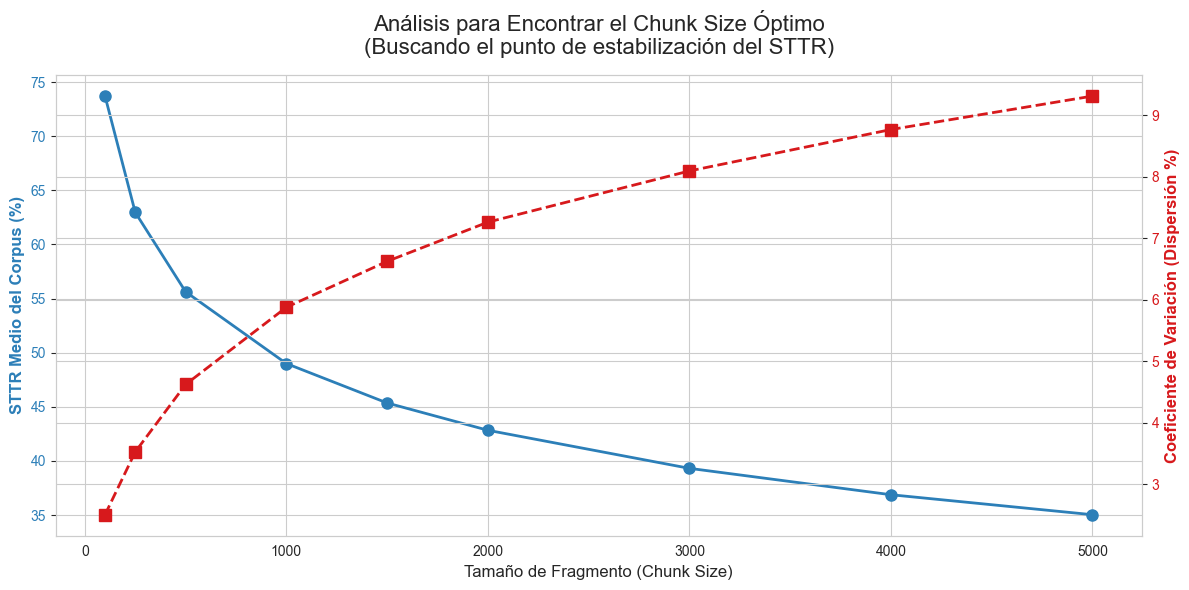


RESULTADOS DE SENSIBILIDAD:
 Chunk_Size  STTR_Medio  Desviacion_Std  Coeficiente_Variacion
        100   73.700845        1.846145               2.504917
        250   62.955042        2.219862               3.526107
        500   55.621691        2.570786               4.621912
       1000   48.990556        2.878764               5.876161
       1500   45.349113        3.003377               6.622792
       2000   42.828189        3.109120               7.259518
       3000   39.311296        3.180922               8.091624
       4000   36.873446        3.231755               8.764450
       5000   35.027974        3.260490               9.308245


In [23]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. Configuración de parámetros a evaluar
# =========================================================
RUTA_TEXTOS = "Textos"
# Lista de chunk sizes para probar
CHUNKS_A_PROBAR = [100, 250, 500, 1000, 1500, 2000, 3000, 4000, 5000]

# =========================================================
# 2. Funciones Base
# =========================================================
def obtener_palabras(texto):
    """Extrae la lista de palabras limpias de un texto."""
    return re.findall(r'\b[a-záéíóúñ]{2,}\b', texto.lower())

def calcular_sttr_base(palabras, chunk_size):
    """Calcula el STTR dado una lista de palabras y un tamaño específico."""
    if len(palabras) < chunk_size:
        return np.nan # Ignorar si el texto es más corto que el chunk
        
    ttrs = []
    for i in range(0, len(palabras) - chunk_size + 1, chunk_size):
        chunk = palabras[i:i+chunk_size]
        ttrs.append(len(set(chunk)) / chunk_size)
        
    return np.mean(ttrs) * 100

# =========================================================
# 3. Procesamiento y Conteo del Corpus
# =========================================================
print("Leyendo el corpus y determinando longitudes...")
corpus = {}
longitudes = []

# Cargar textos en memoria y contar palabras
for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
            palabras = obtener_palabras(f.read())
            if len(palabras) > 0:
                corpus[archivo] = palabras
                longitudes.append((archivo, len(palabras)))

# Identificar la novela más corta (el límite máximo estricto para el chunk)
df_longitudes = pd.DataFrame(longitudes, columns=["Archivo", "Num_Palabras"]).sort_values(by="Num_Palabras")
novela_mas_corta = df_longitudes.iloc[0]
limite_maximo = novela_mas_corta["Num_Palabras"]

print("\n" + "="*50)
print(f"TAMAÑO DEL CORPUS: {len(corpus)} novelas")
print(f"NOVELA MÁS CORTA: '{novela_mas_corta['Archivo']}' con {limite_maximo:,} palabras.")
print(f"   (Ningún chunk size puede ser mayor a {limite_maximo:,})")
print("="*50 + "\n")

# Filtrar los chunks a probar para no exceder el texto más corto
chunks_validos = [c for c in CHUNKS_A_PROBAR if c <= limite_maximo]

# =========================================================
# 4. Cálculo de STTR iterativo
# =========================================================
print("Ejecutando análisis para distintos Chunks")
resultados = []

for chunk in chunks_validos:
    sttr_values = []
    for archivo, palabras in corpus.items():
        val = calcular_sttr_base(palabras, chunk)
        if not np.isnan(val):
            sttr_values.append(val)
    
    # Calcular métricas estadísticas para este chunk size
    if sttr_values:
        media_sttr = np.mean(sttr_values)
        desviacion_sttr = np.std(sttr_values)
        # Coeficiente de variación (qué tanto se dispersan los datos en relación a la media)
        cv = (desviacion_sttr / media_sttr) * 100 
        
        resultados.append({
            "Chunk_Size": chunk,
            "STTR_Medio": media_sttr,
            "Desviacion_Std": desviacion_sttr,
            "Coeficiente_Variacion": cv
        })

df_resultados = pd.DataFrame(resultados)

# =========================================================
# 5. Visualización para Toma de Decisiones
# =========================================================
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico 1: Caída del STTR (Eje Y izquierdo)
color1 = '#2c7fb8'
ax1.set_xlabel('Tamaño de Fragmento (Chunk Size)', fontsize=12)
ax1.set_ylabel('STTR Medio del Corpus (%)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(df_resultados['Chunk_Size'], df_resultados['STTR_Medio'], marker='o', color=color1, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)

# Gráfico 2: Estabilización de la dispersión / CV (Eje Y derecho)
ax2 = ax1.twinx()  
color2 = '#d7191c'
ax2.set_ylabel('Coeficiente de Variación (Dispersión %)', color=color2, fontsize=12, fontweight='bold')
ax2.plot(df_resultados['Chunk_Size'], df_resultados['Coeficiente_Variacion'], marker='s', color=color2, linewidth=2, linestyle='--', markersize=8)
ax2.tick_params(axis='y', labelcolor=color2)

# Título y guardado
plt.title("Análisis para Encontrar el Chunk Size Óptimo\n(Buscando el punto de estabilización del STTR)", fontsize=16, pad=15)
fig.tight_layout()
plt.savefig("Optimizacion_Chunk_Size.pdf", format="pdf", bbox_inches="tight")
plt.show()

# =========================================================
# 6. Diagnóstico Automático
# =========================================================
print("\nRESULTADOS DE SENSIBILIDAD:")
print(df_resultados.to_string(index=False))

📚 Calculando Riqueza Léxica (STTR) y asignando Género...


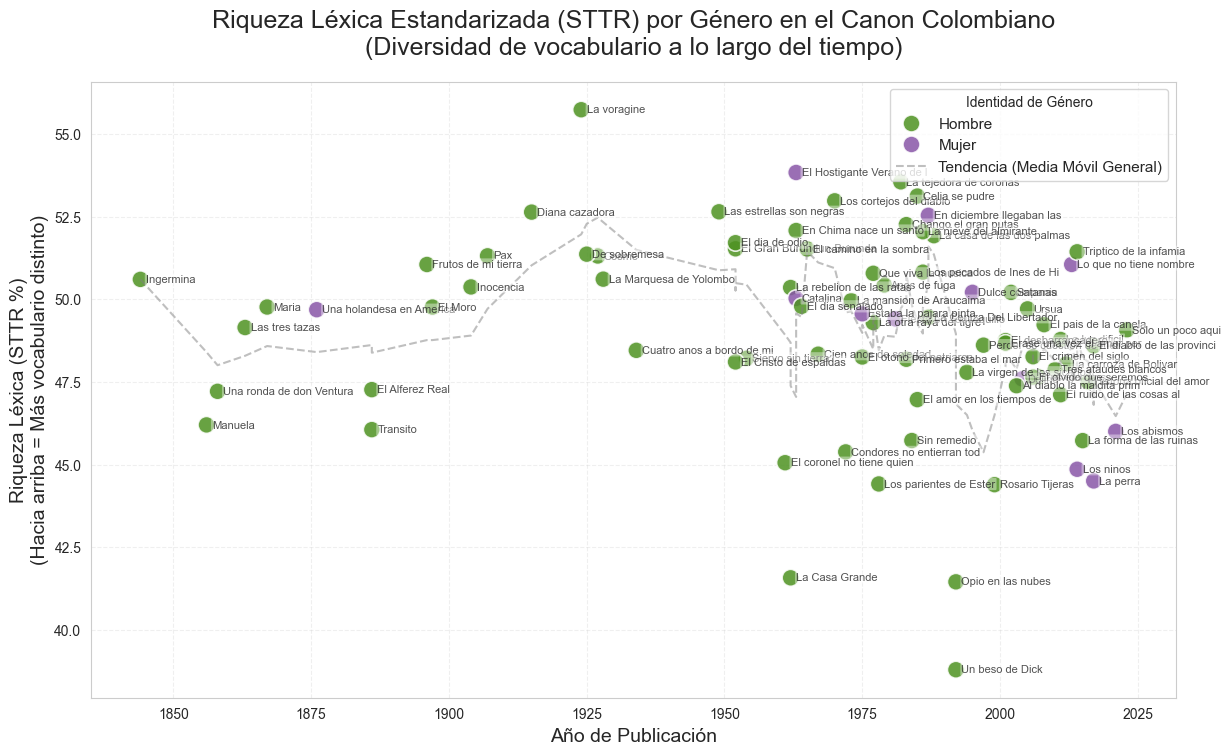


PROMEDIO DE RIQUEZA LÉXICA:
Género
Hombre    48.97
Mujer     49.11
Name: Riqueza_STTR, dtype: float64

TOP 3 NOVELAS MÁS RICAS LÉXICAMENTE (ESCRITAS POR MUJERES):
                            Título          Autor  Riqueza_STTR
El Hostigante Verano de los dioses Fanny Buitrago     53.832927
  En diciembre llegaban las brisas  Marvel Moreno     52.538060
            Lo que no tiene nombre Piedad Bonnett     51.051852


In [24]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# =========================================================
# 1. Funciones de Cálculo y Clasificación
# =========================================================
def calcular_sttr(texto, chunk_size=1000):
    palabras = re.findall(r'\b[a-záéíóúñ]{2,}\b', texto.lower())
    if len(palabras) < chunk_size:
        return len(set(palabras)) / len(palabras) if palabras else 0
        
    ttrs = []
    for i in range(0, len(palabras) - chunk_size + 1, chunk_size):
        chunk = palabras[i:i+chunk_size]
        ttrs.append(len(set(chunk)) / chunk_size)
        
    return np.mean(ttrs) * 100 

def clasificar_genero(autor):
    
    autor_lower = autor.lower()
    
    # Excepción masculina común en el S. XIX
    if "josé maría" in autor_lower or "jose maria" in autor_lower:
        return "Hombre"
        
    # Nombres de escritoras canonizadas en Colombia
    nombres_mujeres = [
        "marvel", "laura", "pilar", "piedad", "albalucía", "albalucia", 
        "soledad", "elisa", "fanny", "helena", "flor", "margarita", 
        "carolina", "melba", "hazel", "ángela", "angela", "gabriela", 
        "emma", "virginia", "carmen", "alba", "amira"
    ]
    
    primer_nombre = autor_lower.split()[0] if autor_lower else ""
    
    if primer_nombre in nombres_mujeres or any(n in autor_lower for n in nombres_mujeres):
        return "Mujer"
    else:
        return "Hombre"

# =========================================================
# 2. Procesamiento de los Textos
# =========================================================
RUTA_TEXTOS = "Textos" 
datos_riqueza = []

print("📚 Calculando Riqueza Léxica (STTR) y asignando Género...")

for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        with open(os.path.join(RUTA_TEXTOS, archivo), 'r', encoding='utf-8') as f:
            texto = f.read()
            
        partes = archivo.replace(".txt", "").split("_")
        anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 0
        autor = partes[1].strip() if len(partes) > 1 else "Desconocido"
        titulo = partes[2].strip() if len(partes) > 2 else archivo.replace(".txt", "")
        
        if anio > 1800:
            sttr_val = calcular_sttr(texto)
            
            datos_riqueza.append({
                "Año": anio,
                "Autor": autor,
                "Título": titulo,
                "Género": clasificar_genero(autor),
                "Riqueza_STTR": sttr_val
            })

df_sttr = pd.DataFrame(datos_riqueza)

# =========================================================
# 3. Visualización Estilística: El Canon y el Género
# =========================================================
paleta_genero = {
    "Mujer": "#8856a7",  
    "Hombre": "#4d9221"  
}

plt.figure(figsize=(14, 8))

# Gráfico de dispersión
ax = sns.scatterplot(
    data=df_sttr,
    x="Año",
    y="Riqueza_STTR",
    hue="Género",
    palette=paleta_genero,
    s=150, 
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

# Línea de tendencia general
df_trend = df_sttr.sort_values(by="Año")
plt.plot(df_trend["Año"], df_trend["Riqueza_STTR"].rolling(5, min_periods=1).mean(), 
         color='grey', linestyle='--', alpha=0.5, label="Tendencia (Media Móvil General)")

plt.title("Riqueza Léxica Estandarizada (STTR) por Género en el Canon Colombiano\n(Diversidad de vocabulario a lo largo del tiempo)", fontsize=18, pad=20)
plt.xlabel("Año de Publicación", fontsize=14)
plt.ylabel("Riqueza Léxica (STTR %)\n(Hacia arriba = Más vocabulario distinto)", fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')

plt.legend(title="Identidad de Género", fontsize=11, loc='upper right')

# Etiquetas
for i in range(len(df_sttr)):
    x = df_sttr["Año"].iloc[i]
    y = df_sttr["Riqueza_STTR"].iloc[i]
    titulo = df_sttr["Título"].iloc[i]
    
    plt.text(x + 1, y, titulo[:25], fontsize=8, alpha=0.8, va='center',
             bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.1'))

plt.savefig("Evolucion_STTR_por_Genero.pdf", format="pdf", bbox_inches="tight")
plt.show()

# =========================================================
# 4. Análisis Sociológico en Consola
# =========================================================
print("\n" + "="*60)
print("PROMEDIO DE RIQUEZA LÉXICA:")
print("="*60)
promedios = df_sttr.groupby("Género")["Riqueza_STTR"].mean().round(2)
print(promedios)

mujeres_df = df_sttr[df_sttr["Género"] == "Mujer"].sort_values(by="Riqueza_STTR", ascending=False)
print("\n" + "="*60)
print("TOP 3 NOVELAS MÁS RICAS LÉXICAMENTE (ESCRITAS POR MUJERES):")
print("="*60)
print(mujeres_df.head(3)[["Título", "Autor", "Riqueza_STTR"]].to_string(index=False))

In [ ]:
import os
import re

def contar_tokens_corpus(ruta_carpeta):
    total_tokens = 0
    total_libros = 0
    
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"): 
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            with open(ruta_completa, 'r', encoding='utf-8') as f:
                texto = f.read()
                # Extraemos las palabras usando tu expresión regular original
                palabras = re.findall(r'\b[a-záéíóúñ]{2,}\b', texto.lower())
                total_tokens += len(palabras)
                total_libros += 1
                
    print(f"Total de libros procesados: {total_libros}")
    print(f"Total de tokens en el corpus: {total_tokens:,}")

contar_tokens_corpus('/Users/clockwork/Proyecto_Canon/textos')

Total de libros procesados: 82
Total de tokens en el corpus: 6,035,070


In [5]:
pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 39.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 47.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 26.9 MB/s  0:00:00
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/12 [sympy]
    Found existing installation: setuptools 82.0.1━━━━━━━━━━━━  2/12 [sympy]
    Uninstalling setuptools-82.0.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/12 [sympy]
      Successfully uninstalled setuptools-82.0.1━━━━━━━━━━━━━━━━━━  3/12 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [stanza]11/12 [stanza]k]s]

[notice] A new release of pip is available: 2

In [ ]:
import stanza
stanza.download('es')

2026-06-17 16:09:27 INFO: Downloaded file to /Users/clockwork/Library/Caches/stanza/1.12.0/resources/resources.json
2026-06-17 16:09:27 INFO: Downloading default packages for language: es (Spanish) ...
2026-06-17 16:09:39 INFO: Downloaded file to /Users/clockwork/Library/Caches/stanza/1.12.0/resources/es/default.zip
2026-06-17 16:09:41 INFO: Finished downloading models and saved to /Users/clockwork/Library/Caches/stanza/1.12.0/resources


[['zip', 'default.zip']]

Verificando y descargando modelos de Stanza


2026-07-01 15:51:47 INFO: Downloaded file to /Users/clockwork/Library/Caches/stanza/1.12.0/resources/resources.json
2026-07-01 15:51:47 WARNING: Language es package default expects mwt, which has been added
2026-07-01 15:51:47 INFO: Downloading these customized packages for language: es (Spanish)...
| Processor       | Package           |
---------------------------------------
| tokenize        | combined_nocharlm |
| mwt             | combined          |
| pos             | combined_charlm   |
| pretrain        | conll17           |
| backward_charlm | newswiki          |
| forward_charlm  | newswiki          |

2026-07-01 15:51:47 INFO: File exists: /Users/clockwork/Library/Caches/stanza/1.12.0/resources/es/tokenize/combined_nocharlm.pt
2026-07-01 15:51:47 INFO: File exists: /Users/clockwork/Library/Caches/stanza/1.12.0/resources/es/mwt/combined.pt
2026-07-01 15:51:47 INFO: File exists: /Users/clockwork/Library/Caches/stanza/1.12.0/resources/es/pos/combined_charlm.pt
2026-07-01 15:5

Cargando modelo lingüístico de Stanza


2026-07-01 15:51:47 INFO: Downloaded file to /Users/clockwork/Library/Caches/stanza/1.12.0/resources/resources.json
2026-07-01 15:51:47 WARNING: Language es package default expects mwt, which has been added
2026-07-01 15:51:47 INFO: Loading these models for language: es (Spanish):
| Processor | Package           |
---------------------------------
| tokenize  | combined_nocharlm |
| mwt       | combined          |
| pos       | combined_charlm   |

2026-07-01 15:51:47 INFO: Using device: cpu
2026-07-01 15:51:47 INFO: Loading: tokenize
2026-07-01 15:51:47 INFO: Loading: mwt
2026-07-01 15:51:47 INFO: Loading: pos
2026-07-01 15:51:48 INFO: Done loading processors!


🎬 Iniciando análisis de Acción (Verbos) vs. Descripción (Adjetivos)...


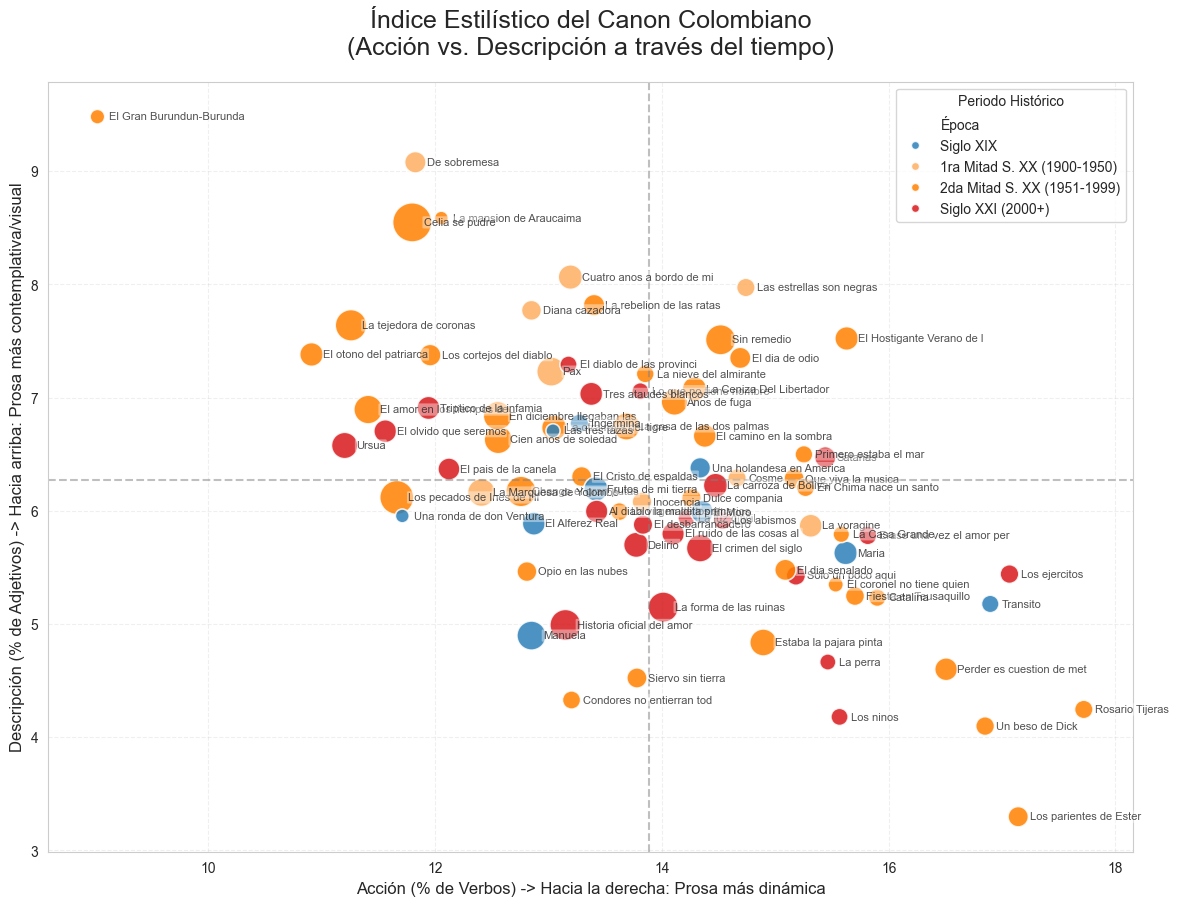


¡Gráfico exportado!


In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import stanza
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# =========================================================
# 1. Función para categorizar épocas
# =========================================================
def categorizar_epoca(anio):
    if anio <= 1899:
        return "Siglo XIX"
    elif 1900 <= anio <= 1950:
        return "1ra Mitad S. XX (1900-1950)"
    elif 1951 <= anio <= 1999:
        return "2da Mitad S. XX (1951-1999)"
    else:
        return "Siglo XXI (2000+)"

# =========================================================
# 2. Modelo NLP y procesamiento de textos
# =========================================================
print("Verificando y descargando modelos de Stanza")
stanza.download('es', processors='tokenize,pos')

print("Cargando modelo lingüístico de Stanza")
# Tokenización y POS 
nlp = stanza.Pipeline(lang='es', processors='tokenize,pos')

RUTA_TEXTOS = "Textos"
datos_accion = []

print("🎬 Iniciando análisis de Acción (Verbos) vs. Descripción (Adjetivos)...")

for archivo in os.listdir(RUTA_TEXTOS):
    if archivo.endswith(".txt") and not archivo.startswith("."):
        ruta_completa = os.path.join(RUTA_TEXTOS, archivo)
        
        with open(ruta_completa, 'r', encoding='utf-8') as f:
            texto = f.read()
            
        # Procesar con Stanza
        doc = nlp(texto)
        
        total_palabras = 0
        verbos = 0
        adjetivos = 0
        
        # Iteración sobre las oraciones y luego sobre cada palabra
        for sentence in doc.sentences:
            for word in sentence.words:
                # Filtrar puntuación, números, símbolos y strings vacíos
                if word.upos not in ["PUNCT", "NUM", "SYM"] and word.text.strip() != "":
                    total_palabras += 1
                    
                    if word.upos == "VERB":
                        verbos += 1
                    elif word.upos == "ADJ":
                        adjetivos += 1
                    
        if total_palabras > 0:
            pct_verbos = (verbos / total_palabras) * 100
            pct_adjetivos = (adjetivos / total_palabras) * 100
        else:
            pct_verbos = 0
            pct_adjetivos = 0
            
        partes = archivo.replace(".txt", "").split("_")
        anio = int(partes[0].strip()) if partes[0].strip().isdigit() else 0
        titulo = partes[2].strip() if len(partes) > 2 else archivo.replace(".txt", "")

        datos_accion.append({
            "Año": anio,
            "Época": categorizar_epoca(anio),
            "Título": titulo,
            "%_Verbos": pct_verbos,
            "%_Adjetivos": pct_adjetivos,
            "Total_Palabras": total_palabras
        })

df_accion = pd.DataFrame(datos_accion)
df_accion = df_accion[df_accion["Año"] > 1800] 

# =========================================================
# 3. Visualización Estilística (Categórica)
# =========================================================
paleta = {
    "Siglo XIX": "#2c7fb8",                   
    "1ra Mitad S. XX (1900-1950)": "#fdae61", 
    "2da Mitad S. XX (1951-1999)": "#ff8000", 
    "Siglo XXI (2000+)": "#d7191c"            
}

plt.figure(figsize=(14, 10))

ax = sns.scatterplot(
    data=df_accion,
    x="%_Verbos",
    y="%_Adjetivos",
    hue="Época",
    hue_order=["Siglo XIX", "1ra Mitad S. XX (1900-1950)", "2da Mitad S. XX (1951-1999)", "Siglo XXI (2000+)"],
    palette=paleta,
    size="Total_Palabras",
    sizes=(100, 800), 
    alpha=0.85,
    edgecolor="white",
    linewidth=1.2
)

promedio_verbos = df_accion["%_Verbos"].mean()
promedio_adjetivos = df_accion["%_Adjetivos"].mean()
plt.axvline(promedio_verbos, color='grey', linestyle='--', alpha=0.5, label="Promedio Verbos")
plt.axhline(promedio_adjetivos, color='grey', linestyle='--', alpha=0.5, label="Promedio Adjetivos")

plt.title("Índice Estilístico del Canon Colombiano\n(Acción vs. Descripción a través del tiempo)", fontsize=18, pad=20)
plt.xlabel("Acción (% de Verbos) -> Hacia la derecha: Prosa más dinámica", fontsize=12)
plt.ylabel("Descripción (% de Adjetivos) -> Hacia arriba: Prosa más contemplativa/visual", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

h, l = ax.get_legend_handles_labels()
epoca_index = l.index("Época") if "Época" in l else 0
plt.legend(h[epoca_index:epoca_index+5], l[epoca_index:epoca_index+5], title="Periodo Histórico", fontsize=10, loc='upper right')

# =========================================================
# 4. Etiquetado Completo 
# =========================================================
for i in range(len(df_accion)):
    x = df_accion["%_Verbos"].iloc[i]
    y = df_accion["%_Adjetivos"].iloc[i]
    titulo = df_accion["Título"].iloc[i]
    
    plt.text(x + 0.1, y, titulo[:25], fontsize=8, alpha=0.8, va='center',
             bbox=dict(facecolor='white', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.1'))

plt.savefig("Accion_vs_Descripcion_Categorico_Completo_Stanza.pdf", format="pdf", bbox_inches="tight")
plt.show()

# =========================================================
# 5. Reporte de Consola
# =========================================================
print("\n¡Gráfico exportado!")

In [ ]:
df_accion.to_csv("resultados_stanza.csv", index=False)


Novelas comparadas: 82

Verbos  — r = 0.9864, p = 1.82e-64
Adjetivos — r = 0.9932, p = 1.93e-76


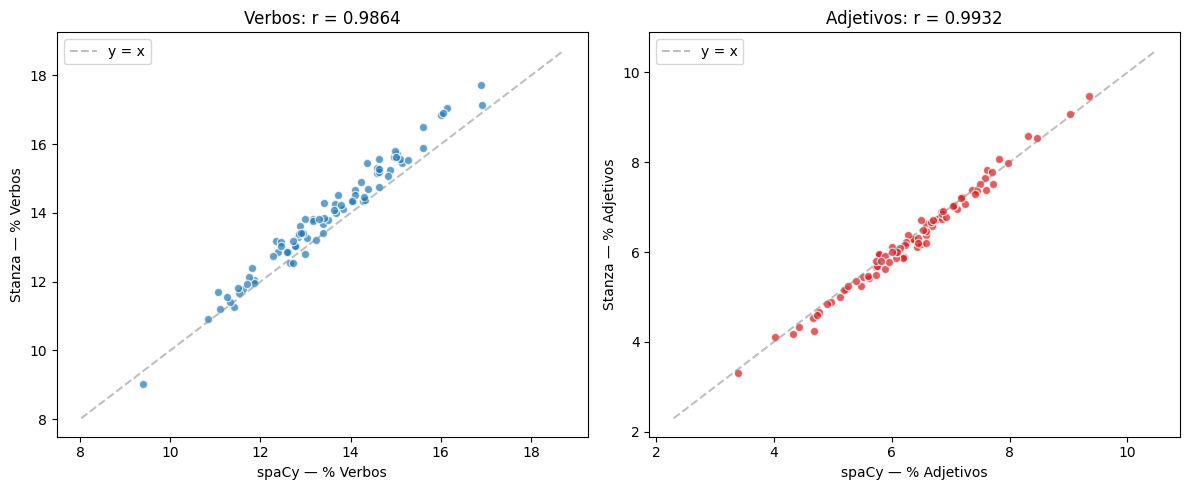


Novelas con mayor discrepancia en verbos:
                          Título   Año  %_Verbos_spacy  %_Verbos_stanza  \
18                       Satanas  2002       14.358067        15.441253   
76                La Casa Grande  1962       14.634051        15.582348   
4                  Los ejercitos  2007       16.131855        17.065710   
38  Perder es cuestion de metodo  1997       15.602078        16.507224   
31      La Ceniza Del Libertador  1987       13.416556        14.287884   

    diff_verbos  
18     1.083187  
76     0.948296  
4      0.933855  
38     0.905146  
31     0.871328  

Novelas con mayor discrepancia en adjetivos:
                    Título   Año  %_Adjetivos_spacy  %_Adjetivos_stanza  \
77         Rosario Tijeras  1999           4.678304            4.245924   
57  En Chima nace un santo  1963           6.586345            6.206101   
24             La voragine  1924           6.197578            5.868404   
6          El Alferez Real  1886           6.205808 

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Cargar ambos resultados
spacy_df = pd.read_csv("resultados_spacy.csv")
stanza_df = pd.read_csv("resultados_stanza.csv")

# Renombrar columnas antes del merge para distinguirlas
spacy_df = spacy_df.rename(columns={
    "%_Verbos": "%_Verbos_spacy",
    "%_Adjetivos": "%_Adjetivos_spacy"
})
stanza_df = stanza_df.rename(columns={
    "%_Verbos": "%_Verbos_stanza",
    "%_Adjetivos": "%_Adjetivos_stanza"
})

# Merge por Título
df = pd.merge(
    spacy_df[["Título", "Año", "%_Verbos_spacy", "%_Adjetivos_spacy"]],
    stanza_df[["Título", "%_Verbos_stanza", "%_Adjetivos_stanza"]],
    on="Título",
    how="inner"  # Solo novelas presentes en ambos
)

print(f"Novelas comparadas: {len(df)}")

# ─── Correlaciones de Pearson ───────────────────────────────────────────
r_verbos, p_verbos = stats.pearsonr(df["%_Verbos_spacy"], df["%_Verbos_stanza"])
r_adj,    p_adj    = stats.pearsonr(df["%_Adjetivos_spacy"], df["%_Adjetivos_stanza"])

print(f"\nVerbos  — r = {r_verbos:.4f}, p = {p_verbos:.2e}")
print(f"Adjetivos — r = {r_adj:.4f}, p = {p_adj:.2e}")

# ─── Scatter de validación ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(df["%_Verbos_spacy"], df["%_Verbos_stanza"], alpha=0.7, edgecolors='white')
ax1.set_xlabel("spaCy — % Verbos")
ax1.set_ylabel("Stanza — % Verbos")
ax1.set_title(f"Verbos: r = {r_verbos:.4f}")

# Línea diagonal ideal (x = y)
lim = [df[["%_Verbos_spacy", "%_Verbos_stanza"]].min().min() - 1,
       df[["%_Verbos_spacy", "%_Verbos_stanza"]].max().max() + 1]
ax1.plot(lim, lim, '--', color='grey', alpha=0.5, label="y = x")
ax1.legend()

ax2.scatter(df["%_Adjetivos_spacy"], df["%_Adjetivos_stanza"], alpha=0.7,
            color='#d7191c', edgecolors='white')
ax2.set_xlabel("spaCy — % Adjetivos")
ax2.set_ylabel("Stanza — % Adjetivos")
ax2.set_title(f"Adjetivos: r = {r_adj:.4f}")

lim2 = [df[["%_Adjetivos_spacy", "%_Adjetivos_stanza"]].min().min() - 1,
        df[["%_Adjetivos_spacy", "%_Adjetivos_stanza"]].max().max() + 1]
ax2.plot(lim2, lim2, '--', color='grey', alpha=0.5, label="y = x")
ax2.legend()

plt.tight_layout()
plt.savefig("validacion_modelos.svg", format="svg", bbox_inches="tight")
plt.show()

# ─── Identificar outliers ────────
df["diff_verbos"] = (df["%_Verbos_spacy"] - df["%_Verbos_stanza"]).abs()
df["diff_adjetivos"] = (df["%_Adjetivos_spacy"] - df["%_Adjetivos_stanza"]).abs()

print("\nNovelas con mayor discrepancia en verbos:")
print(df.nlargest(5, "diff_verbos")[["Título", "Año", "%_Verbos_spacy", "%_Verbos_stanza", "diff_verbos"]])

print("\nNovelas con mayor discrepancia en adjetivos:")
print(df.nlargest(5, "diff_adjetivos")[["Título", "Año", "%_Adjetivos_spacy", "%_Adjetivos_stanza", "diff_adjetivos"]])

In [ ]:
import pandas as pd

spacy_df = pd.read_csv("resultados_spacy.csv")
stanza_df = pd.read_csv("resultados_stanza.csv")

# Verificar diferencia
print(spacy_df.equals(stanza_df))

# Ver los promedios de cada uno
print("\nspaCy:")
print(spacy_df[["%_Verbos", "%_Adjetivos"]].mean())

print("\nStanza:")
print(stanza_df[["%_Verbos", "%_Adjetivos"]].mean())

False

spaCy:
%_Verbos       13.471306
%_Adjetivos     6.336279
dtype: float64

Stanza:
%_Verbos       13.889242
%_Adjetivos     6.273676
dtype: float64


In [17]:
from scipy import stats

r_verbos, p_verbos = stats.pearsonr(df["%_Verbos_spacy"], df["%_Verbos_stanza"])
r_adj, p_adj = stats.pearsonr(df["%_Adjetivos_spacy"], df["%_Adjetivos_stanza"])

print(f"Verbos    — r = {r_verbos:.4f}, p = {p_verbos:.2e}")
print(f"Adjetivos — r = {r_adj:.4f},    p = {p_adj:.2e}")

Verbos    — r = 0.9864, p = 1.82e-64
Adjetivos — r = 0.9932,    p = 1.93e-76
